# Part 4 — Dynamic Scheduler Analysis

For each run this notebook produces a three-panel figure with shared x-axis:
- Top Gantt chart: which color-coded job runs on which core at each moment in time.
- Middle: QPS left y-axis and p95 read latency with the 0.8 ms SLO line in the right y-axis.
- Bottom: per-core CPU utilization (%) from the `cpu_N.csv` logged by the controller.

A combined p95-only overlay across all runs follows.

Section index:
- [Q1 Memcached T/C characterisation](#q1)
- [Q3 Dynamic scheduler for 15 s intervals](#q3)
- [Q4 Dynamic scheduler for 5 s intervals](#q4)

In [67]:
import re
import csv
import io
import glob
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# Experiment parameters
Q1_DIR = Path("../data/p4/q1")
Q3_DIR = Path("../data/p4/q3")
Q4_DIR = Path("../data/p4/q4")
RUNS = [1, 2, 3]

Q3_INTERVAL_S = 15
Q4_INTERVAL_S = 5

SLO_MS = 0.8
SLO_US = SLO_MS * 1000

TOTAL_CORES = 4

# Figure output directories: one subfolder per report section, under p4/
FIGURES_DIR = Path("../reports/figures")
FIG_Q1     = FIGURES_DIR / "p4" / "q1"
FIG_Q3     = FIGURES_DIR / "p4" / "q3"
FIG_Q4     = FIGURES_DIR / "p4" / "q4"
FIG_SEARCH = FIGURES_DIR / "p4" / "search"
for _d in [FIG_Q1, FIG_Q3, FIG_Q4, FIG_SEARCH]:
    _d.mkdir(parents=True, exist_ok=True)

In [68]:
# Color map: colors match the report template
JOB_COLORS = {
    "memcached": "#1f77b4",  # not in template, keep a neutral blue
    "barnes": "#AACCCA",
    "blackscholes": "#CCA000",
    "canneal": "#CCCCAA",
    "freqmine": "#0CCA00",
    "radix": "#00CCA0",
    "streamcluster": "#CCACCA",
    "vips": "#CC0A00",
}
JOBS_ORDER = list(JOB_COLORS.keys())

In [69]:
# Parsers for Q3, Q4

def parse_mcperf(path: Path):
    """Return (unix_start_s, list of per-interval dicts with p95, qps, target)."""
    unix_start = None
    intervals = []
    with open(path) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith("Timestamp start:"):
                unix_start = int(line.split(":", 1)[1].strip()) / 1_000
            elif line.startswith("read"):
                cols = line.split()
                intervals.append({
                    "p95": float(cols[12]),
                    "qps": float(cols[16]),
                    "target": float(cols[17]),
                })
    return unix_start, intervals


def parse_core_list(token: str) -> list:
    return [int(x) for x in re.findall(r"\d+", token)]


def parse_jobs(path: Path):
    """Return (scheduler_start_dt, events), timestamps tagged UTC."""
    import urllib.parse

    scheduler_start = None
    events = []
    last_cores = {}
    with open(path) as fh:
        for line in fh:
            parts = line.strip().split(maxsplit=3)
            if not parts:
                continue
            ts = datetime.fromisoformat(parts[0]).replace(tzinfo=timezone.utc)
            etype = parts[1]
            job = parts[2] if len(parts) > 2 else None
            arg = parts[3] if len(parts) > 3 else ""
            if job == "scheduler":
                if etype == "start":
                    scheduler_start = ts
                continue

            core_arg = arg.split()[0] if arg else ""
            if etype == "start":
                cores = parse_core_list(core_arg)
                last_cores[job] = cores
                events.append({"t": ts, "type": etype, "job": job, "cores": cores})
            elif etype == "update_cores":
                cores = parse_core_list(core_arg)
                last_cores[job] = cores
                events.append({"t": ts, "type": etype, "job": job, "cores": cores})
            elif etype == "pause":
                events.append({"t": ts, "type": etype, "job": job, "cores": []})
            elif etype == "unpause":
                events.append({"t": ts, "type": etype, "job": job, "cores": last_cores.get(job, [])})
            elif etype == "end":
                events.append({"t": ts, "type": etype, "job": job, "cores": []})
            elif etype == "custom":
                comment = urllib.parse.unquote_plus(arg)
                if comment == "paused" or comment.startswith("slot_A_guard_pause"):
                    events.append({"t": ts, "type": "pause", "job": job, "cores": []})
                elif comment == "unpaused" or comment.startswith("slot_A_guard_unpause"):
                    events.append({"t": ts, "type": "unpause", "job": job, "cores": last_cores.get(job, [])})
                else:
                    continue
    return scheduler_start, events


def build_gantt(scheduler_start, events, t_end):
    state = {}
    segments = []

    def flush(job, until_s):
        if job not in state or not state[job]["cores"]:
            return
        t0 = state[job]["t_start"]
        dur = until_s - t0
        if dur > 0:
            for core in state[job]["cores"]:
                segments.append((job, core, t0, dur))

    for ev in sorted(events, key=lambda e: e["t"]):
        job = ev["job"]
        t_s = (ev["t"] - scheduler_start).total_seconds()
        flush(job, t_s)
        if ev["type"] == "end":
            state.pop(job, None)
        else:
            state[job] = {"cores": ev["cores"], "t_start": t_s}
    for job in list(state.keys()):
        flush(job, t_end)
    return segments


def parse_cpu_log(path: Path, scheduler_start):
    times = []
    cores = [[], [], [], []]
    try:
        with open(path, newline="") as fh:
            reader = csv.DictReader(fh)
            for row in reader:
                ts = datetime.fromisoformat(row["timestamp"]).replace(tzinfo=timezone.utc)
                t_s = (ts - scheduler_start).total_seconds()
                times.append(t_s)
                for i in range(4):
                    key = f"core{i}"
                    cores[i].append(float(row[key]) if key in row else 0.0)
    except FileNotFoundError:
        pass
    return times, cores

In [70]:
# Three-panel plot function requested for Q3, Q4

def _fig_path(data_dir: Path, run: int) -> Path:
    """Return the full save path for a per-run three-panel figure.

    Mapping (data_dir.name -> reports/figures subfolder / filename):
      q3          -> q3/q3_run{N}.pdf
      q4          -> q4/q4_run{N}.pdf
      q4-int3     -> q4/q4_int3_run{N}.pdf
      q4-int{N}   -> q4/q4_int{N}_run{N}.pdf
    """
    name = data_dir.name
    if name == "q3":
        return FIG_Q3 / f"q3_run{run}.pdf"
    if name == "q4":
        return FIG_Q4 / f"q4_run{run}.pdf"
    if name.startswith("search/"):
        policy = name.replace("search/", "")
        return FIG_SEARCH / f"search_{policy}_run{run}.pdf"
    # "q4-int3" -> strip "part-4-" -> "q4-int3" -> replace "-" -> "q4_int3"
    prefix = name.replace("part-4-", "").replace("-", "_")
    return FIG_Q4 / f"{prefix}_run{run}.pdf"


def plot_run(data_dir: Path, run: int, interval_s: int, label: str = ""):
    mcperf_path = data_dir / f"run_{run}" / f"mcperf_{run}.txt"
    jobs_path = data_dir / f"run_{run}" / f"jobs_{run}.txt"
    cpu_path = data_dir / f"run_{run}" / f"cpu_{run}.csv"

    unix_start, intervals = parse_mcperf(mcperf_path)
    sched_start, events = parse_jobs(jobs_path)

    # Fallback: if jobs log is missing or empty, use mcperf unix_start as t=0
    has_jobs = sched_start is not None
    if not has_jobs:
        sched_start = datetime.fromtimestamp(unix_start, tz=timezone.utc)

    mcperf_offset = unix_start - sched_start.timestamp()
    t_mid = [mcperf_offset + (i + 0.5) * interval_s for i in range(len(intervals))]
    t_end_s = mcperf_offset + len(intervals) * interval_s

    p95_us = [iv["p95"] for iv in intervals]
    qps = [iv["qps"] for iv in intervals]

    gantt_segs = build_gantt(sched_start, events, t_end_s)
    cpu_times, cpu_data = parse_cpu_log(cpu_path, sched_start)
    has_cpu = len(cpu_times) > 0

    fig, axes = plt.subplots(
        3, 1, figsize=(15, 9), sharex=True,
        gridspec_kw={"height_ratios": [1.5, 2, 1.5], "hspace": 0.05},
    )
    fig.suptitle(f"Part 4 - {label}Run {run}  with interval={interval_s}s",
                 fontsize=13, fontweight="bold")
    ax_gantt, ax_lat, ax_cpu = axes

    # Gantt
    for (job, core, t0, dur) in gantt_segs:
        ax_gantt.broken_barh([(t0, dur)], (core - 0.4, 0.8),
                             facecolors=JOB_COLORS.get(job, "black"),
                             edgecolors="white", linewidth=0.3)
    ax_gantt.set_yticks(range(TOTAL_CORES))
    ax_gantt.set_yticklabels([f"Core {c}" for c in range(TOTAL_CORES)], fontsize=9)
    ax_gantt.set_ylabel("CPU core", fontsize=10)
    ax_gantt.set_ylim(-0.6, TOTAL_CORES - 0.4)
    ax_gantt.grid(axis="x", ls=":", alpha=0.4)
    if not has_jobs:
        ax_gantt.text(0.5, 0.5, "jobs log not available for this run",
                      ha="center", va="center", transform=ax_gantt.transAxes,
                      fontsize=11, color="grey", style="italic")
    else:
        seen = {seg[0] for seg in gantt_segs}
        ax_gantt.legend(
            handles=[mpatches.Patch(color=JOB_COLORS[j], label=j)
                     for j in JOBS_ORDER if j in seen],
            fontsize=8, loc="upper right", ncol=4, framealpha=0.8)

    # QPS + p95
    c_qps, c_lat = "#7f7f7f", "#1f77b4"
    ax_lat.fill_between(t_mid, [q / 1000 for q in qps], alpha=0.15, color=c_qps, step="mid")
    ax_lat.step(t_mid, [q / 1000 for q in qps], where="mid", color=c_qps, lw=1.0, label="QPS (K)")
    ax_lat.set_ylabel("QPS (K)", fontsize=10, color=c_qps)
    ax_lat.tick_params(axis="y", labelcolor=c_qps)
    ax_lat.set_ylim(bottom=0)
    ax_lat.grid(axis="y", ls=":", alpha=0.3)

    ax_p95 = ax_lat.twinx()
    ax_p95.plot(t_mid, p95_us, marker="o", ms=2.5, lw=1.2, color=c_lat, label="p95 latency")
    ax_p95.axhline(SLO_US, color="red", lw=1.5, ls="--", label=f"SLO {SLO_MS} ms")
    violations = [(t, p) for t, p in zip(t_mid, p95_us) if p > SLO_US]
    if violations:
        ax_p95.scatter(*zip(*violations), color="red", s=40, zorder=5,
                       label=f"Violation ({len(violations)}x)")
    ax_p95.set_ylabel("p95 latency (µs)", fontsize=10, color=c_lat)
    ax_p95.tick_params(axis="y", labelcolor=c_lat)
    ax_p95.set_ylim(bottom=0)
    l1, lb1 = ax_lat.get_legend_handles_labels()
    l2, lb2 = ax_p95.get_legend_handles_labels()
    ax_p95.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper right")

    # Per-core CPU
    core_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    if has_cpu:
        for i in range(TOTAL_CORES):
            ax_cpu.plot(cpu_times, cpu_data[i], lw=0.8,
                        color=core_colors[i], alpha=0.85, label=f"Core {i}")
        ax_cpu.legend(fontsize=8, loc="upper right", ncol=2)
    else:
        ax_cpu.text(0.5, 0.5, "cpu_N.csv not available",
                    ha="center", va="center", transform=ax_cpu.transAxes,
                    fontsize=11, color="grey")
    ax_cpu.set_ylabel("CPU util (% / core)", fontsize=10)
    x_label = "Time from scheduler start (s)" if has_jobs else "Time from mcperf start (s)"
    ax_cpu.set_xlabel(x_label, fontsize=10)
    ax_cpu.set_ylim(-2, 105)
    ax_cpu.axhline(100, color="black", lw=0.6, ls=":")
    ax_cpu.grid(axis="y", ls=":", alpha=0.4)

    fp = _fig_path(data_dir, run)
    plt.savefig(fp, bbox_inches="tight")
    plt.show()

    n_viol, n_int = len(violations), len(intervals)
    print(f"Run {run}: {n_viol}/{n_int} SLO violations ({100 * n_viol / n_int:.1f}%)")
    print(f"  max p95 = {max(p95_us):.1f} µs  |  mean p95 = {np.mean(p95_us):.1f} µs")
    if has_cpu:
        print(f"  CPU utilization per core:")
        all_vals = []
        for i in range(TOTAL_CORES):
            vals = np.array(cpu_data[i])
            all_vals.extend(vals.tolist())
            print(f"    Core {i}: mean={np.mean(vals):5.1f}%  max={np.max(vals):5.1f}%  std={np.std(vals):5.1f}%")
        all_vals = np.array(all_vals)
        print(f"    Total:  mean={np.mean(all_vals):5.1f}%  max={np.max(all_vals):5.1f}%  std={np.std(all_vals):5.1f}%")
    if not has_jobs:
        print(f"  (jobs log was empty, Gantt not shown, x-axis is relative to mcperf start)")
    print(f"  -> saved: {fp}")
    print()

<a id='q1'></a>
## Q1a Memcached T/C Configuration Sweep

Sweep range is 5 K–125 K QPS.

Data collected with `make start-part-4-1` with results in `data/p4/q1/`.
- Q1a: 9 configs (T in {1,2,3} * C in {1,2,3}), 3 runs each - latency vs. QPS.
- Q1d: T chosen from Q1c where C in {1,2,3}, 1 run - latency left y-axis + CPU util right y-axis per C.

In [71]:
# Q1 helpers
import io as _io


def parse_mcperf_scan(filepath):
    """Parse a --scan mcperf log, return DataFrame with QPS, p95_ms columns."""
    with open(filepath) as f:
        lines = f.readlines()
    table = [l for l in lines if l.startswith('#') or l.startswith('read')]
    df = pd.read_csv(_io.StringIO(''.join(table)), sep=r'\s+')
    df.columns = [c.replace('#', '') for c in df.columns]
    df['p95_ms'] = df['p95'] / 1000.0
    return df[['target', 'QPS', 'p95_ms']]


def parse_pidstat_cpu(filepath):
    """
    Parse pidstat -u output, return list of (sample_index, cpu_pct) tuples.
    The %CPU column reports total CPU across all threads, which can exceed 100%.
    """
    readings = []
    try:
        with open(filepath) as f:
            for line in f:
                parts = line.split()
                # Data lines: timestamp  UID  PID  %usr  %system  %guest  %wait  %CPU  CPU  Command
                # Skip header/blank/summary lines
                if len(parts) < 9:
                    continue
                if parts[-1] not in ('memcached',):
                    continue
                try:
                    cpu_pct = float(parts[7])  # %CPU column
                    readings.append(cpu_pct)
                except (ValueError, IndexError):
                    pass
    except FileNotFoundError:
        pass
    return readings


# Load Q1a data
Q1A_CONFIGS = [(T, C) for T in [1, 2, 3] for C in [1, 2, 3]]
Q1A_RUNS = [1, 2, 3]
Q1A_SLO_MS = SLO_MS

q1a_rows = []
for T, C in Q1A_CONFIGS:
    for run in Q1A_RUNS:
        p = Q1_DIR / "q1a" / f"t{T}_c{C}_run{run}.txt"
        if not p.exists():
            continue
        df = parse_mcperf_scan(p)
        df['T'] = T;
        df['C'] = C;
        df['run'] = run
        q1a_rows.append(df)

if q1a_rows:
    q1a_df = pd.concat(q1a_rows, ignore_index=True)
    q1a_stats = q1a_df.groupby(['T', 'C', 'target']).agg(
        qps_mean=('QPS', 'mean'), qps_std=('QPS', 'std'),
        p95_mean=('p95_ms', 'mean'), p95_std=('p95_ms', 'std'),
        n_runs=('run', 'count'),
    ).reset_index()
    print(f"Q1a: {len(q1a_rows)} files loaded, "
          f"{q1a_df['target'].nunique()} QPS steps, "
          f"{q1a_df.groupby(['T', 'C']).ngroups} T/C configs")
else:
    q1a_stats = None
    print("Q1a data not yet available - run: make start-part-4-1")

Q1a: 27 files loaded, 13 QPS steps, 9 T/C configs


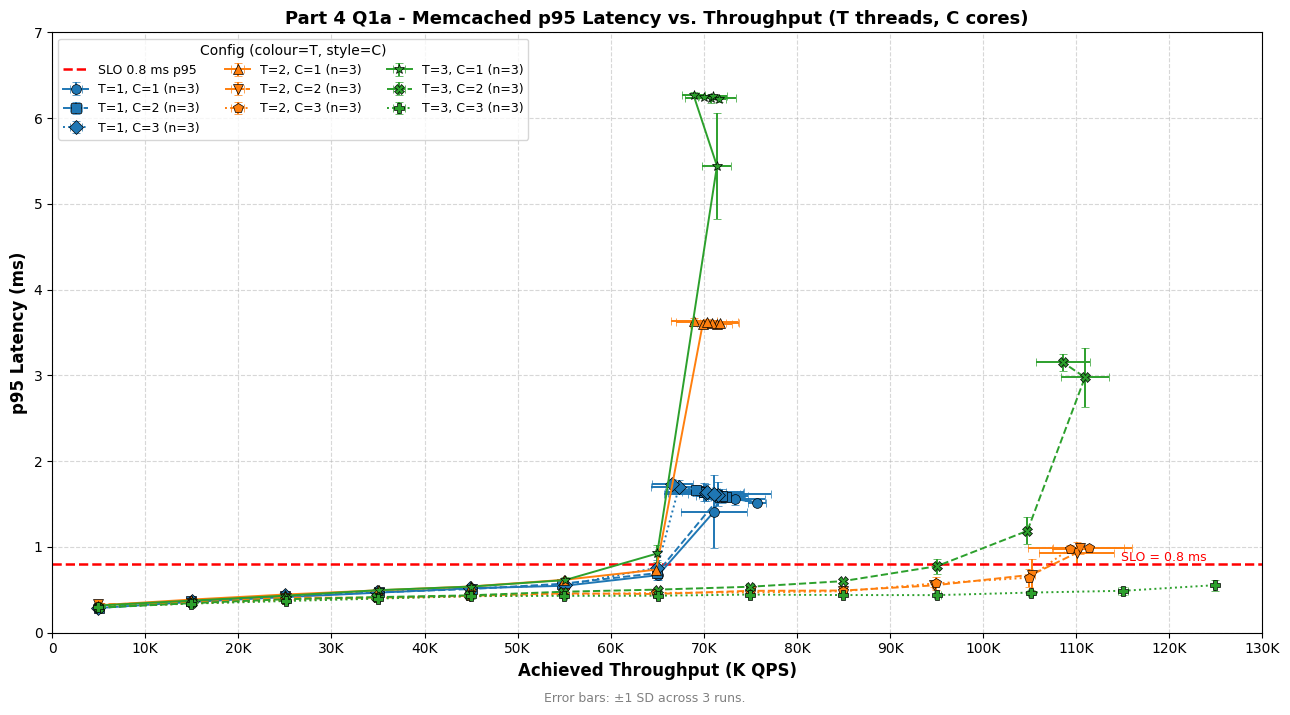


Config           Max QPS within SLO   p95 there (ms)  SLO first violated at
----------------------------------------------------------------------------
T=1, C=1                        65.1K            0.671                    75K
T=1, C=2                        65.0K            0.695                    75K
T=1, C=3                        65.0K            0.758                    75K
T=2, C=1                        64.9K            0.735                    75K
T=2, C=2                       105.2K            0.676                   115K
T=2, C=3                       105.0K            0.642                   115K
T=3, C=1                        55.1K            0.613                    65K
T=3, C=2                        95.0K            0.775                   105K
T=3, C=3                       124.9K            0.554                  >125K


In [72]:
# Q1a Plot: p95 latency vs. QPS for all 9 T/C configurations
if q1a_stats is None:
    print("No Q1a data - skipping plot.")
else:
    import matplotlib as mpl

    cmap = mpl.colormaps['tab10']
    markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P']
    # Line style distinguishes C; colour distinguishes T
    T_colors = {1: cmap(0), 2: cmap(1), 3: cmap(2)}
    C_linestyle = {1: '-', 2: '--', 3: ':'}

    fig, ax = plt.subplots(figsize=(13, 7))

    for idx, (T, C) in enumerate(Q1A_CONFIGS):
        sub = q1a_stats[(q1a_stats['T'] == T) & (q1a_stats['C'] == C)].sort_values('target')
        if sub.empty:
            continue
        n = int(sub['n_runs'].iloc[0])
        ax.errorbar(
            sub['qps_mean'] / 1000, sub['p95_mean'],
            xerr=sub['qps_std'] / 1000, yerr=sub['p95_std'],
            label=f"T={T}, C={C} (n={n})",
            marker=markers[idx], markersize=7,
            markeredgecolor='black', markeredgewidth=0.5,
            capsize=3, linestyle=C_linestyle[C],
            linewidth=1.4, color=T_colors[T],
        )

    ax.axhline(Q1A_SLO_MS, color='red', lw=1.8, ls='--',
               label=f'SLO {Q1A_SLO_MS} ms p95')
    ax.text(124, Q1A_SLO_MS + 0.04, f'SLO = {Q1A_SLO_MS} ms',
            color='red', ha='right', fontsize=9)

    ax.set_title('Part 4 Q1a - Memcached p95 Latency vs. Throughput (T threads, C cores)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Achieved Throughput (K QPS)', fontsize=12, fontweight='bold')
    ax.set_ylabel('p95 Latency (ms)', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: '0' if x == 0 else f'{x:.0f}K'))
    ax.set_xlim(0, 130)
    ax.set_xticks(range(0, 131, 10))
    ax.set_ylim(0, 7)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(title='Config (colour=T, style=C)', loc='upper left',
              fontsize=9, ncol=3, frameon=True)
    fig.text(0.5, -0.01, 'Error bars: ±1 SD across 3 runs.',
             ha='center', fontsize=9, color='grey')
    plt.tight_layout()
    plt.savefig(FIG_Q1 / 'q1a_latency_vs_qps.pdf', bbox_inches='tight')
    plt.show()

    # Max sustainable QPS table
    print(f"\n{'Config':<12} {'Max QPS within SLO':>22} {'p95 there (ms)':>16} {'SLO first violated at':>22}")
    print('-' * 76)
    for T, C in Q1A_CONFIGS:
        sub = q1a_stats[(q1a_stats['T'] == T) & (q1a_stats['C'] == C)].sort_values('target')
        within = sub[sub['p95_mean'] <= Q1A_SLO_MS]
        violated = sub[sub['p95_mean'] > Q1A_SLO_MS]
        max_qps = f"{within['qps_mean'].iloc[-1] / 1000:.1f}K" if not within.empty else "0"
        p95_at = f"{within['p95_mean'].iloc[-1]:.3f}" if not within.empty else "N/A"
        first_viol = (f"{violated['target'].iloc[0] / 1000:.0f}K"
                      if not violated.empty else ">125K")
        print(f"T={T}, C={C}       {max_qps:>22} {p95_at:>16} {first_viol:>22}")

### Q1d Latency + CPU Utilization

All T values per core count.

The script collects data for all T in {1,2,3} at each C,
so we can show empirically why a particular T is the right choice for Q1c,
rather than just picking the maximum.

For each C the graph overlays three latency curves, one per T,
and three CPU-utilization curves, making two things visible:
- which T values respect the 0.8 ms SLO across the full QPS range.
- whether adding more cores actually helps, i.e. does CPU scale with C.

The final subsection reproduces the single-T graph required by the handout.

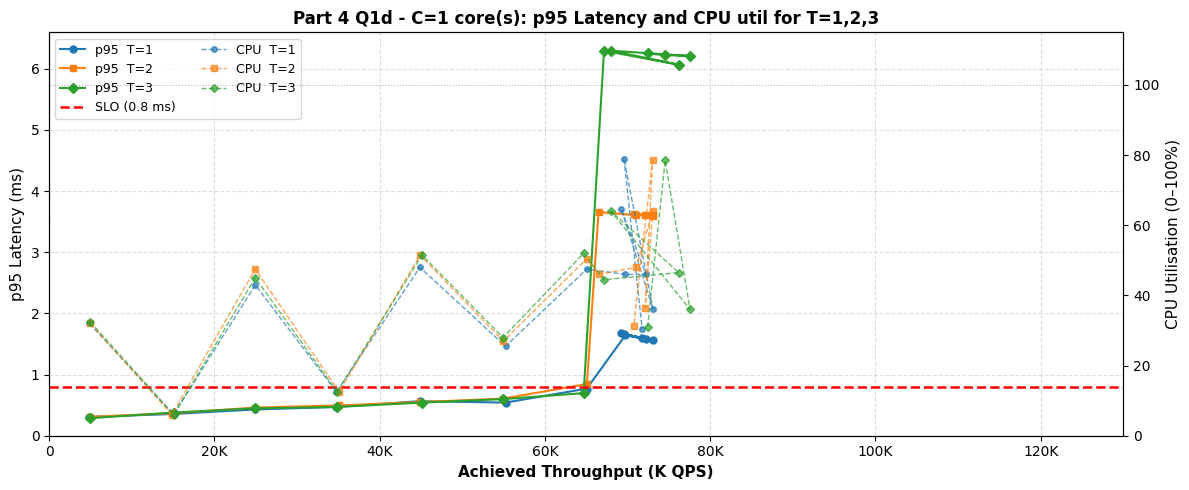

C=1 max QPS within SLO per thread count:
  T=1: max QPS within SLO =   65K   peak CPU = 79.0%
  T=2: max QPS within SLO =   55K   peak CPU = 78.5%
  T=3: max QPS within SLO =   65K   peak CPU = 78.5%



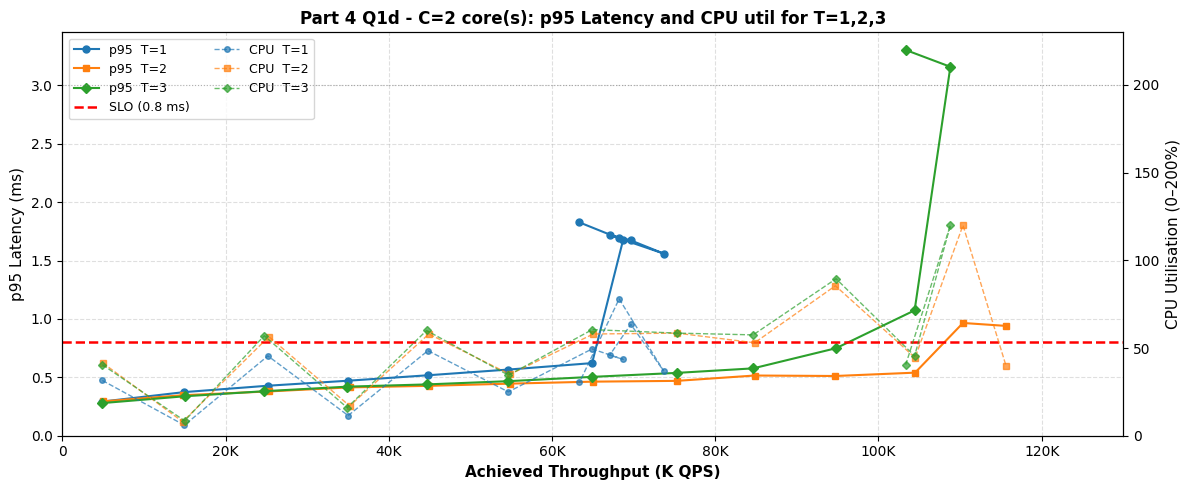

C=2 max QPS within SLO per thread count:
  T=1: max QPS within SLO =   65K   peak CPU = 78.0%
  T=2: max QPS within SLO =  104K   peak CPU = 120.0%
  T=3: max QPS within SLO =   95K   peak CPU = 120.0%



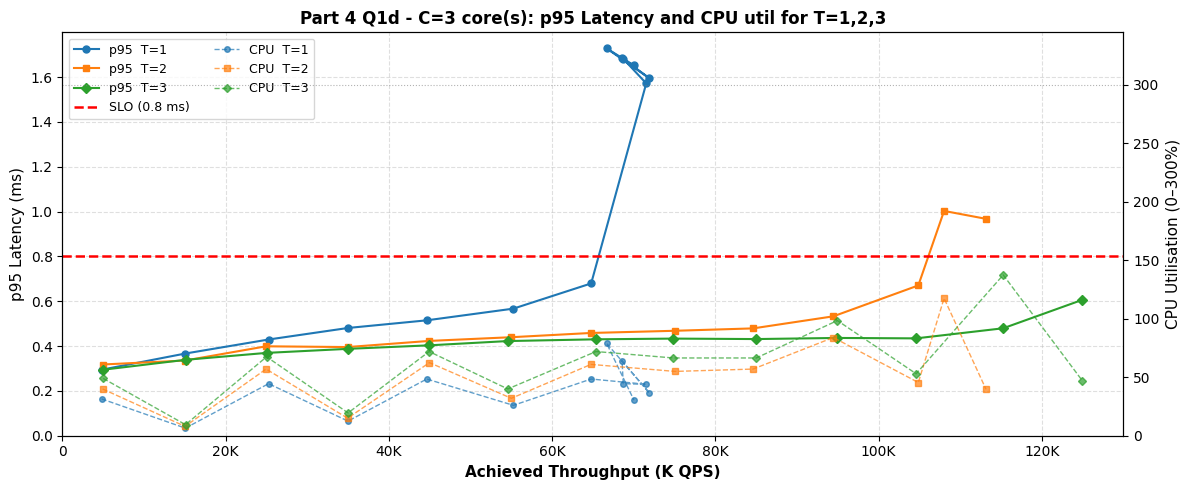

C=3 max QPS within SLO per thread count:
  T=1: max QPS within SLO =   65K   peak CPU = 79.0%
  T=2: max QPS within SLO =  105K   peak CPU = 117.5%
  T=3: max QPS within SLO =  125K   peak CPU = 137.5%



In [73]:
# Q1d parsers

def parse_pidstat_cpu(filepath):
    """
    Parse pidstat -u output; return list of %CPU readings for the memcached
    process.  %CPU can exceed 100 % for multi-threaded processes, as it sums
    across all hardware threads the process is using.
    """
    readings = []
    try:
        with open(filepath) as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 10 and parts[-1] == 'memcached':
                    try:
                        readings.append(float(parts[7]))
                    except ValueError:
                        pass
    except FileNotFoundError:
        pass
    return readings


def load_q1d_config(T, C):
    """Return (qps_arr, p95_arr, cpu_arr) for a Q1d (T, C) run, or None."""
    mp = Q1_DIR / "q1d" / f"t{T}_c{C}_mcperf.txt"
    cp = Q1_DIR / "q1d" / f"t{T}_c{C}_cpu.txt"
    if not mp.exists():
        return None
    df = parse_mcperf_scan(mp)
    qps = df['QPS'].values / 1000
    p95_ms = df['p95_ms'].values
    n = len(p95_ms)
    cpu_raw = parse_pidstat_cpu(cp)
    if len(cpu_raw) > n:
        cpu_raw = cpu_raw[-n:]
    cpu = np.array(cpu_raw + [np.nan] * max(0, n - len(cpu_raw)))
    return qps, p95_ms, cpu


import matplotlib as mpl_mod

T_COLORS = {1: mpl_mod.colormaps['tab10'](0),
            2: mpl_mod.colormaps['tab10'](1),
            3: mpl_mod.colormaps['tab10'](2)}
T_MARKERS = {1: 'o', 2: 's', 3: 'D'}

any_q1d = any(
    (Q1_DIR / "q1d" / f"t{T}_c{C}_mcperf.txt").exists()
    for T in [1, 2, 3] for C in [1, 2, 3]
)

if not any_q1d:
    print("Q1d data not yet available - run: make start-part-4-1")
else:
    for C in [1, 2, 3]:
        fig, ax_lat = plt.subplots(figsize=(12, 5))
        ax_cpu = ax_lat.twinx()

        plotted = False
        for T in [1, 2, 3]:
            result = load_q1d_config(T, C)
            if result is None:
                print(f"  Missing: T={T} C={C}")
                continue
            qps, p95_ms, cpu = result
            col = T_COLORS[T]
            mk = T_MARKERS[T]
            ax_lat.plot(qps, p95_ms, marker=mk, ms=5, lw=1.5,
                        color=col, label=f"p95  T={T}")
            ax_cpu.plot(qps, cpu, marker=mk, ms=4, lw=1.0,
                        color=col, ls='--', alpha=0.7, label=f"CPU  T={T}")
            plotted = True

        if not plotted:
            plt.close()
            continue

        ax_lat.axhline(SLO_MS, color='red', lw=1.8, ls='--', label=f'SLO ({SLO_MS} ms)')
        cpu_max_pct = C * 100
        ax_cpu.axhline(cpu_max_pct, color='grey', lw=0.8, ls=':', alpha=0.6)
        ax_cpu.set_ylim(0, cpu_max_pct * 1.15)
        ax_cpu.set_ylabel(f'CPU Utilisation (0–{cpu_max_pct}%)', fontsize=11)
        ax_lat.set_xlabel('Achieved Throughput (K QPS)', fontsize=11, fontweight='bold')
        ax_lat.set_ylabel('p95 Latency (ms)', fontsize=11)
        ax_lat.set_xlim(0, 130)
        ax_lat.set_ylim(0)
        ax_lat.xaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, _: '0' if x == 0 else f'{x:.0f}K'))
        ax_lat.grid(True, linestyle='--', alpha=0.4)
        l1, lb1 = ax_lat.get_legend_handles_labels()
        l2, lb2 = ax_cpu.get_legend_handles_labels()
        ax_lat.legend(l1 + l2, lb1 + lb2, fontsize=9, loc='upper left', ncol=2, frameon=True)
        plt.title(f'Part 4 Q1d - C={C} core(s): p95 Latency and CPU util for T=1,2,3',
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIG_Q1 / f"q1d_c{C}_all_threads.pdf", bbox_inches='tight')
        plt.show()

        print(f"C={C} max QPS within SLO per thread count:")
        for T in [1, 2, 3]:
            result = load_q1d_config(T, C)
            if result is None: continue
            qps, p95_ms, cpu = result
            ok = qps[p95_ms <= SLO_MS]
            max_ok = f"{ok.max():.0f}K" if len(ok) else "none"
            max_cpu = f"{np.nanmax(cpu):.1f}%" if len(cpu) else "N/A"
            print(f"  T={T}: max QPS within SLO = {max_ok:>5}   peak CPU = {max_cpu}")
        print()

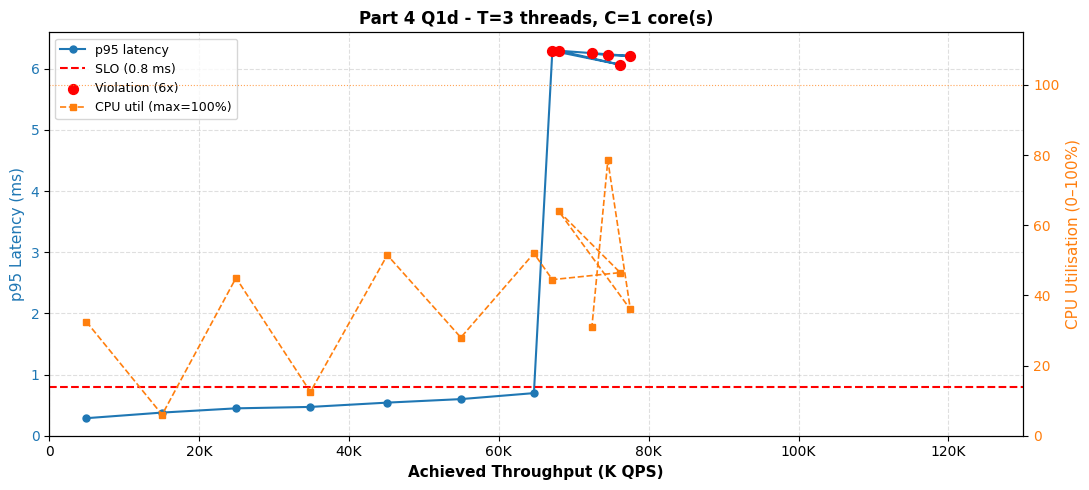

C=1: 6 SLO violation(s)  max p95=6.294 ms  max CPU=78.5%


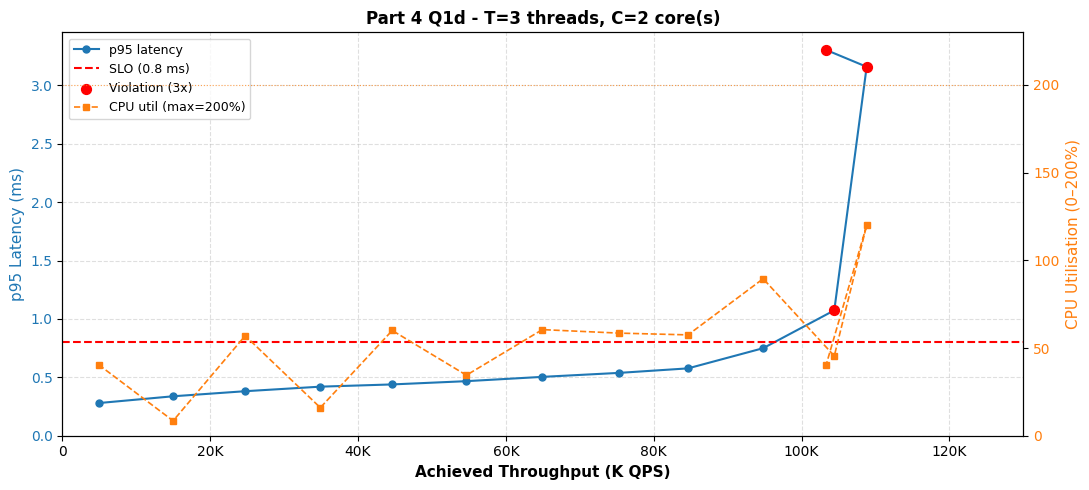

C=2: 3 SLO violation(s)  max p95=3.303 ms  max CPU=120.0%


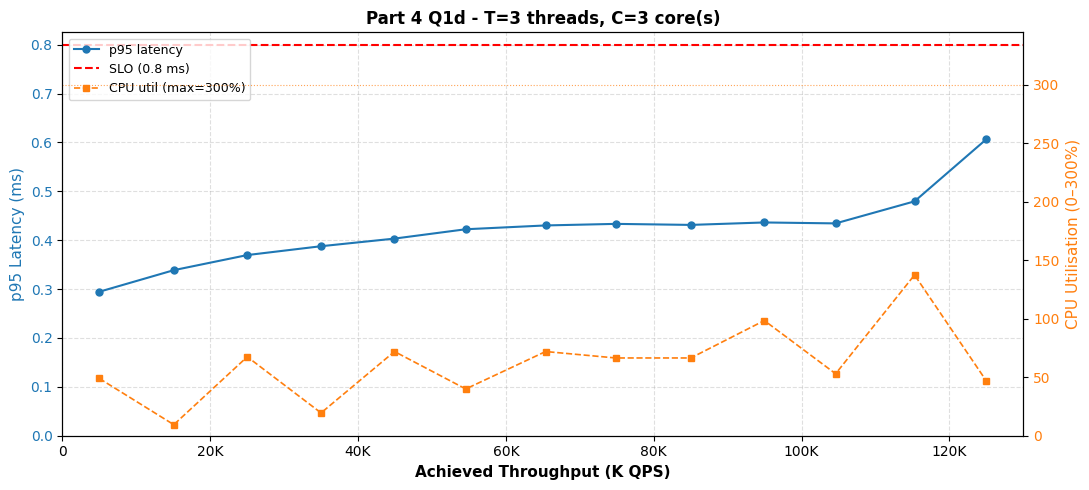

C=3: 0 SLO violation(s)  max p95=0.606 ms  max CPU=137.5%



In [74]:
# Q1d final: three separate graphs for the chosen T in handout format
Q1D_CHOSEN_T = 3

for C in [1, 2, 3]:
    result = load_q1d_config(Q1D_CHOSEN_T, C)
    if result is None:
        print(f"Q1d C={C} T={Q1D_CHOSEN_T}: data not available")
        continue
    qps, p95_ms, cpu = result

    cpu_max_pct = C * 100
    fig, ax_lat = plt.subplots(figsize=(11, 5))
    ax_cpu = ax_lat.twinx()

    ax_lat.plot(qps, p95_ms, marker='o', ms=5, lw=1.5, color='#1f77b4', label='p95 latency')
    ax_lat.axhline(SLO_MS, color='red', lw=1.5, ls='--', label=f'SLO ({SLO_MS} ms)')
    viol = qps[p95_ms > SLO_MS]
    if len(viol):
        ax_lat.scatter(viol, p95_ms[p95_ms > SLO_MS], color='red', s=50, zorder=5,
                       label=f'Violation ({len(viol)}x)')

    ax_cpu.plot(qps, cpu, marker='s', ms=4, lw=1.2, color='#ff7f0e', ls='--',
                label=f'CPU util (max={cpu_max_pct}%)')
    ax_cpu.axhline(cpu_max_pct, color='#ff7f0e', lw=0.8, ls=':', alpha=0.7)
    ax_cpu.set_ylim(0, cpu_max_pct * 1.15)
    ax_cpu.set_ylabel(f'CPU Utilisation (0–{cpu_max_pct}%)', fontsize=11, color='#ff7f0e')
    ax_cpu.tick_params(axis='y', labelcolor='#ff7f0e')

    ax_lat.set_xlabel('Achieved Throughput (K QPS)', fontsize=11, fontweight='bold')
    ax_lat.set_ylabel('p95 Latency (ms)', fontsize=11, color='#1f77b4')
    ax_lat.tick_params(axis='y', labelcolor='#1f77b4')
    ax_lat.set_xlim(0, 130)
    ax_lat.set_ylim(0)
    ax_lat.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: '0' if x == 0 else f'{x:.0f}K'))
    ax_lat.grid(True, linestyle='--', alpha=0.4)

    l1, lb1 = ax_lat.get_legend_handles_labels()
    l2, lb2 = ax_cpu.get_legend_handles_labels()
    ax_lat.legend(l1 + l2, lb1 + lb2, fontsize=9, loc='upper left')
    plt.title(f'Part 4 Q1d - T={Q1D_CHOSEN_T} threads, C={C} core(s)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_Q1 / f"q1d_final_t{Q1D_CHOSEN_T}_c{C}.pdf", bbox_inches='tight')
    plt.show()
    print(f"C={C}: {len(viol)} SLO violation(s)  "
          f"max p95={p95_ms.max():.3f} ms  max CPU={np.nanmax(cpu):.1f}%")
print()

<a id='q3'></a>
## Q3

### Dynamic Scheduler

15-second intervals.

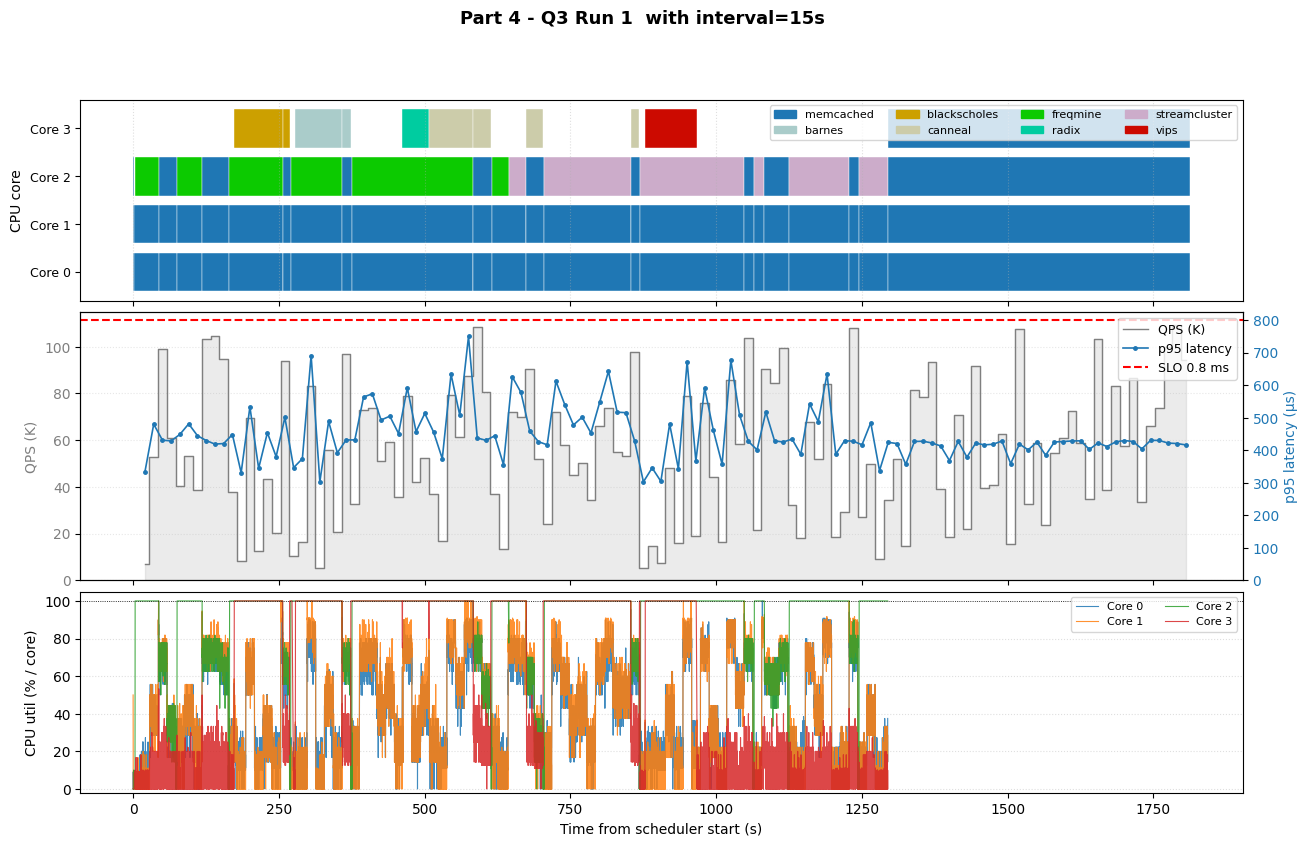

Run 1: 0/120 SLO violations (0.0%)
  max p95 = 750.0 µs  |  mean p95 = 451.1 µs
  CPU utilization per core:
    Core 0: mean= 42.1%  max=100.0%  std= 25.7%
    Core 1: mean= 42.6%  max=100.0%  std= 29.6%
    Core 2: mean= 91.3%  max=100.0%  std= 19.6%
    Core 3: mean= 57.2%  max=100.0%  std= 45.3%
    Total:  mean= 58.3%  max=100.0%  std= 37.3%
  -> saved: ../reports/figures/p4/q3/q3_run1.pdf



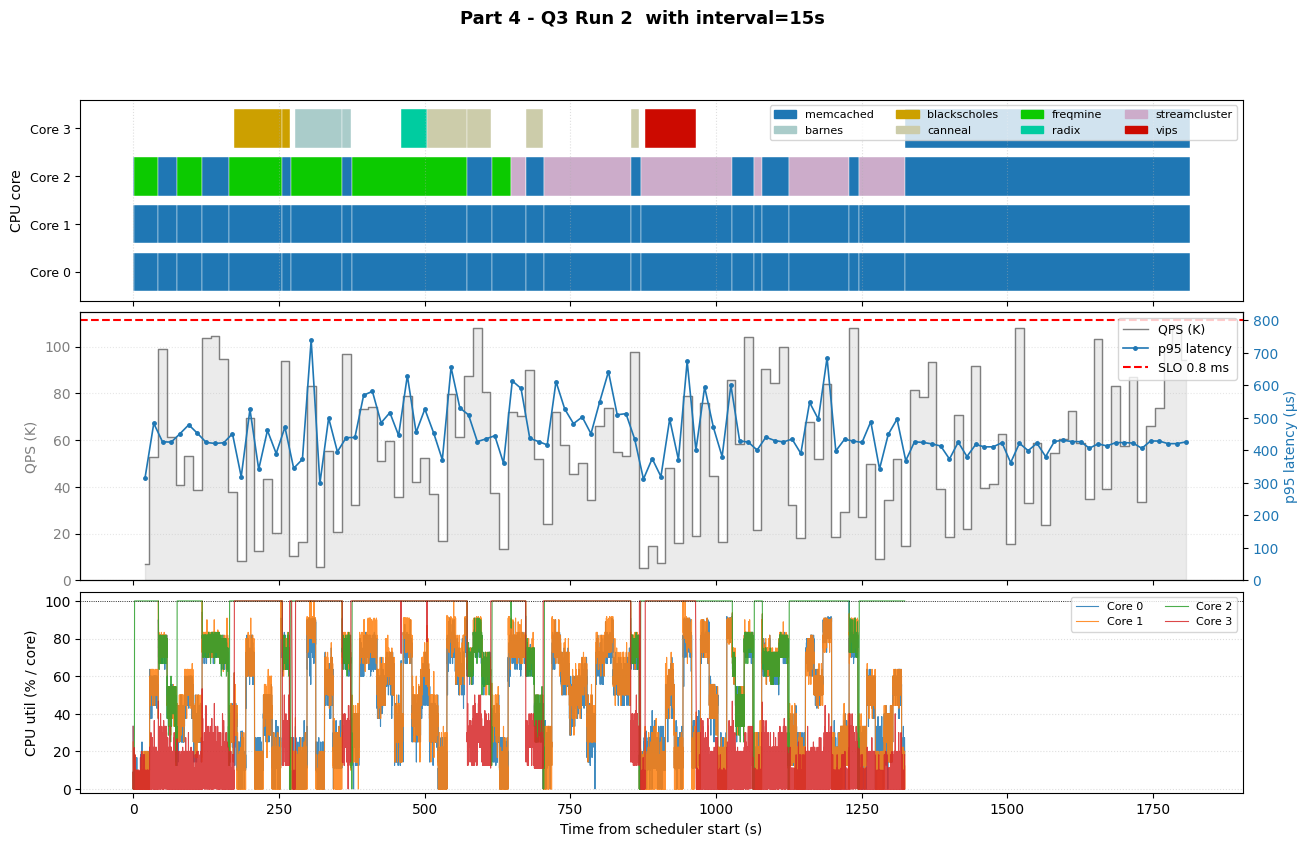

Run 2: 0/120 SLO violations (0.0%)
  max p95 = 739.6 µs  |  mean p95 = 450.6 µs
  CPU utilization per core:
    Core 0: mean= 47.3%  max=100.0%  std= 25.6%
    Core 1: mean= 48.2%  max=100.0%  std= 28.4%
    Core 2: mean= 91.7%  max=100.0%  std= 17.7%
    Core 3: mean= 55.5%  max=100.0%  std= 45.1%
    Total:  mean= 60.7%  max=100.0%  std= 35.8%
  -> saved: ../reports/figures/p4/q3/q3_run2.pdf



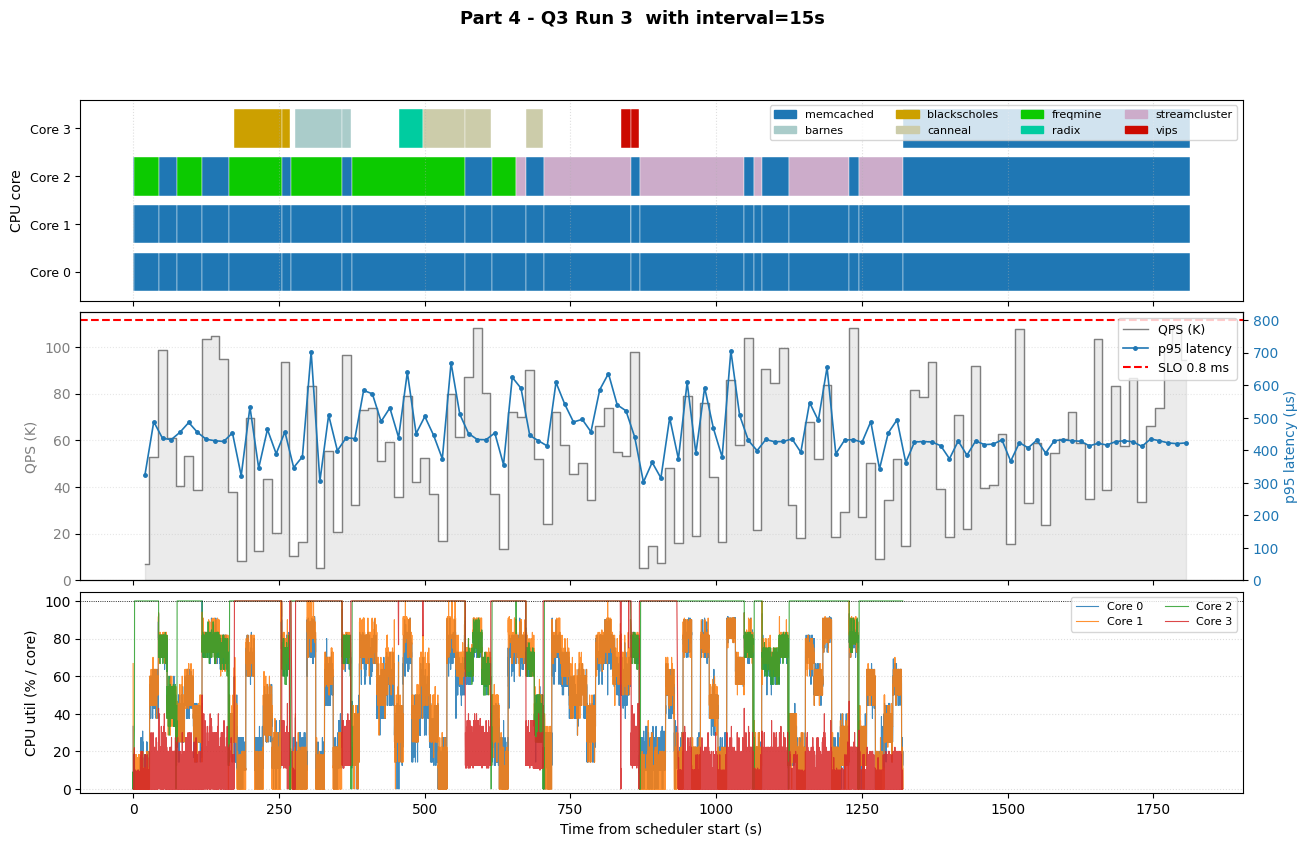

Run 3: 0/120 SLO violations (0.0%)
  max p95 = 705.7 µs  |  mean p95 = 452.9 µs
  CPU utilization per core:
    Core 0: mean= 47.5%  max=100.0%  std= 26.3%
    Core 1: mean= 48.4%  max=100.0%  std= 29.2%
    Core 2: mean= 92.4%  max=100.0%  std= 17.0%
    Core 3: mean= 52.9%  max=100.0%  std= 45.6%
    Total:  mean= 60.3%  max=100.0%  std= 36.4%
  -> saved: ../reports/figures/p4/q3/q3_run3.pdf



In [124]:
for run in RUNS:
    plot_run(Q3_DIR, run, Q3_INTERVAL_S, label="Q3 ")

### Combined p95 overlay

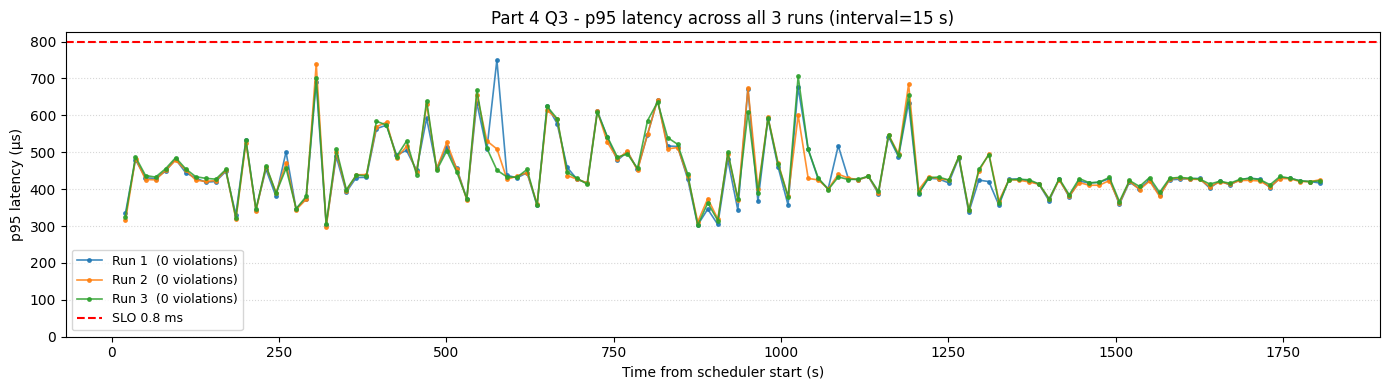

In [125]:
fig, ax = plt.subplots(figsize=(14, 4))
colors_runs = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for run, color in zip(RUNS, colors_runs):
    unix_start, intervals = parse_mcperf(Q3_DIR / f"run_{run}" / f"mcperf_{run}.txt")
    sched_start, _ = parse_jobs(Q3_DIR / f"run_{run}" / f"jobs_{run}.txt")
    mcperf_offset = unix_start - sched_start.timestamp()
    t_mid = [mcperf_offset + (i + 0.5) * Q3_INTERVAL_S for i in range(len(intervals))]
    p95_us = [iv["p95"] for iv in intervals]
    n_viol = sum(1 for p in p95_us if p > SLO_US)
    ax.plot(t_mid, p95_us, marker="o", ms=2.5, lw=1.2, color=color, alpha=0.85,
            label=f"Run {run}  ({n_viol} violations)")
ax.axhline(SLO_US, color="red", lw=1.5, ls="--", label=f"SLO {SLO_MS} ms")
ax.set_xlabel("Time from scheduler start (s)", fontsize=10)
ax.set_ylabel("p95 latency (µs)", fontsize=10)
ax.set_title("Part 4 Q3 - p95 latency across all 3 runs (interval=15 s)", fontsize=12)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(axis="y", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_Q3 / "q3_summary.pdf", bbox_inches="tight")
plt.show()

### Job runtimes, makespan, and SLO violations

Per-job execution time:
mean ± std across 3 runs, total makespan, and SLO violation ratio
during the batch-job execution window, from first container start to last container end.

In [126]:
# Q3: per-job runtimes, makespan, SLO violations
import statistics

JOBS_REPORT_ORDER = [
    "streamcluster", "freqmine", "canneal", "vips",
    "blackscholes", "barnes", "radix",
]


def job_durations_and_window(events):
    """Return (durations_dict, makespan_s, first_batch_start_dt, last_batch_end_dt).

    Ignores memcached and scheduler events, uses only batch job start/end pairs.
    """
    starts = {}
    durations = {}
    first_start = None
    last_end = None
    for ev in sorted(events, key=lambda e: e["t"]):
        job = ev["job"]
        if job in ("memcached",):
            continue
        if ev["type"] == "start":
            starts[job] = ev["t"]
            if first_start is None:
                first_start = ev["t"]
        elif ev["type"] == "end" and job in starts:
            dur = (ev["t"] - starts[job]).total_seconds()
            durations[job] = dur
            last_end = ev["t"]
    makespan = (last_end - first_start).total_seconds() if first_start and last_end else None
    return durations, makespan, first_start, last_end


def slo_violations_in_window(data_dir, run, interval_s, t_start_dt, t_end_dt):
    """Count mcperf intervals with p95 > SLO_US whose midpoint falls within [t_start, t_end]."""
    unix_start, intervals = parse_mcperf(data_dir / f"run_{run}" / f"mcperf_{run}.txt")
    t0_s = t_start_dt.timestamp()
    t1_s = t_end_dt.timestamp()
    total, viols = 0, 0
    for i, iv in enumerate(intervals):
        mid = unix_start + (i + 0.5) * interval_s
        if t0_s <= mid <= t1_s:
            total += 1
            if iv["p95"] > SLO_US:
                viols += 1
    return viols, total


# Collect per-run data
all_durations = {job: [] for job in JOBS_REPORT_ORDER}
makespans = []
slo_results = []

for run in RUNS:
    jobs_path = Q3_DIR / f"run_{run}" / f"jobs_{run}.txt"
    if not jobs_path.exists():
        print(f"Run {run}: jobs_{run}.txt not found -> skipping")
        continue

    _, events = parse_jobs(jobs_path)
    durs, ms, t0, t1 = job_durations_and_window(events)
    makespans.append(ms)

    for job in JOBS_REPORT_ORDER:
        all_durations[job].append(durs.get(job, float("nan")))

    viols, total = slo_violations_in_window(Q3_DIR, run, Q3_INTERVAL_S, t0, t1)
    slo_results.append((run, viols, total))
    print(f"Run {run}: makespan={ms:.1f}s | "
          f"SLO violations={viols}/{total} ({100 * viols / total:.1f}%)")

# Print summary table
print()
print(f"{'Job':<16} {'Mean [s]':>10} {'Std [s]':>10}")
print("-" * 38)
for job in JOBS_REPORT_ORDER:
    vals = [v for v in all_durations[job] if not np.isnan(v)]
    mean = statistics.mean(vals) if vals else float("nan")
    std = statistics.stdev(vals) if len(vals) > 1 else 0.0
    print(f"{job:<16} {mean:>10.1f} {std:>10.1f}")
print("-" * 38)
ms_mean = statistics.mean(makespans) if makespans else float("nan")
ms_std = statistics.stdev(makespans) if len(makespans) > 1 else 0.0
print(f"{'total time':<16} {ms_mean:>10.1f} {ms_std:>10.1f}")

print()
print("SLO violation ratio per run (p95 > 0.8 ms, during batch window):")
for run, viols, total in slo_results:
    ratio = viols / total if total > 0 else 0.0
    print(f"  Run {run}: {viols}/{total} = {ratio:.4f} ({100 * ratio:.2f}%)")

Run 1: makespan=1291.3s | SLO violations=0/85 (0.0%)
Run 2: makespan=1321.5s | SLO violations=0/87 (0.0%)
Run 3: makespan=1318.3s | SLO violations=0/87 (0.0%)

Job                Mean [s]    Std [s]
--------------------------------------
streamcluster         662.9       12.5
freqmine              647.0        6.9
canneal               355.6       14.7
vips                   90.9        5.5
blackscholes          100.2        0.9
barnes                180.3        3.5
radix                  43.7        1.9
--------------------------------------
total time           1310.4       16.6

SLO violation ratio per run (p95 > 0.8 ms, during batch window):
  Run 1: 0/85 = 0.0000 (0.00%)
  Run 2: 0/87 = 0.0000 (0.00%)
  Run 3: 0/87 = 0.0000 (0.00%)


<a id='q4'></a>
## Q4

### Dynamic Scheduler

5-second intervals.

Run `make start-part-4-4 RUN=1`, `RUN=2`, `RUN=3` to collect data first.

### Job runtimes, makespan, and SLO violations

Per-job execution time: mean and std across 3 runs, total makespan, and SLO violation ratio
during the batch-job execution window, from first container start to last container end.
Computed identically to Q3 but with `Q4_INTERVAL_S = 5` s per mcperf measurement step.

In [127]:
# Q4: per-job runtimes, makespan, SLO violations
# Reuses job_durations_and_window() and slo_violations_in_window() defined in the Q3 cell.

q4_all_durations = {job: [] for job in JOBS_REPORT_ORDER}
q4_makespans = []
q4_slo_results = []

for run in RUNS:
    jobs_path = Q4_DIR / f"run_{run}" / f"jobs_{run}.txt"
    if not jobs_path.exists():
        print(f"Run {run}: jobs_{run}.txt not found -> skipping")
        continue

    _, events = parse_jobs(jobs_path)
    durs, ms, t0, t1 = job_durations_and_window(events)

    if t0 is None or t1 is None:
        print(f"Run {run}: jobs log empty, cannot determine batch window")
        continue

    q4_makespans.append(ms)
    for job in JOBS_REPORT_ORDER:
        q4_all_durations[job].append(durs.get(job, float("nan")))

    viols, total = slo_violations_in_window(Q4_DIR, run, Q4_INTERVAL_S, t0, t1)
    q4_slo_results.append((run, viols, total))
    print(f"Run {run}: makespan={ms:.1f}s | "
          f"SLO violations={viols}/{total} ({100 * viols / total:.2f}%) | "
          f"window={t0.strftime('%H:%M:%S')}–{t1.strftime('%H:%M:%S')} ({(t1 - t0).total_seconds():.0f}s)")

# Summary table
print()
print(f"{'Job':<16} {'Mean [s]':>10} {'Std [s]':>10}")
print("-" * 38)
for job in JOBS_REPORT_ORDER:
    vals = [v for v in q4_all_durations[job] if not np.isnan(v)]
    mean = statistics.mean(vals) if vals else float("nan")
    std = statistics.stdev(vals) if len(vals) > 1 else 0.0
    print(f"{job:<16} {mean:>10.1f} {std:>10.1f}")
print("-" * 38)
ms_mean = statistics.mean(q4_makespans) if q4_makespans else float("nan")
ms_std = statistics.stdev(q4_makespans) if len(q4_makespans) > 1 else 0.0
print(f"{'total time':<16} {ms_mean:>10.1f} {ms_std:>10.1f}")

print()
print("SLO violation ratio per run (p95 > 0.8 ms, during batch window):")
total_viols, total_pts = 0, 0
for run, viols, total in q4_slo_results:
    ratio = viols / total if total > 0 else 0.0
    print(f"  Run {run}: {viols}/{total} = {ratio:.4f} ({100 * ratio:.2f}%)")
    total_viols += viols
    total_pts += total
if total_pts > 0:
    print(f"  Overall: {total_viols}/{total_pts} = {total_viols / total_pts:.4f} "
          f"({100 * total_viols / total_pts:.2f}%)")

# Comparison with Q3
print()
print("=== Q3 vs Q4 comparison ===")
print(f"{'Metric':<30} {'Q3 (15s)':>12} {'Q4 (5s)':>12}")
print("-" * 56)
q3_ms_vals = [v for v in makespans if v]  # makespans defined in Q3 cell
print(f"{'Makespan mean [s]':<30} {statistics.mean(q3_ms_vals):>12.1f} {ms_mean:>12.1f}")
print(f"{'Makespan std [s]':<30} {statistics.stdev(q3_ms_vals):>12.1f} {ms_std:>12.1f}")
q3_total_v = sum(v for _, v, _ in slo_results)  # slo_results from Q3 cell
q3_total_p = sum(t for _, _, t in slo_results)
q4_total_v = sum(v for _, v, _ in q4_slo_results)
q4_total_p = sum(t for _, _, t in q4_slo_results)
print(f"{'SLO violations (total)':<30} {q3_total_v:>10}/{q3_total_p} {q4_total_v:>10}/{q4_total_p}")

Run 1: makespan=1640.1s | SLO violations=6/326 (1.84%) | window=06:38:59–07:06:19 (1640s)
Run 2: makespan=1766.9s | SLO violations=1/351 (0.28%) | window=16:32:14–17:01:41 (1767s)
Run 3: makespan=1867.7s | SLO violations=0/360 (0.00%) | window=17:03:08–17:34:16 (1868s)

Job                Mean [s]    Std [s]
--------------------------------------
streamcluster         652.6      229.6
freqmine              627.0       87.1
canneal               326.1       67.6
vips                  139.2       52.0
blackscholes          108.8        4.4
barnes                186.2       25.6
radix                  45.8       13.2
--------------------------------------
total time           1758.2      114.0

SLO violation ratio per run (p95 > 0.8 ms, during batch window):
  Run 1: 6/326 = 0.0184 (1.84%)
  Run 2: 1/351 = 0.0028 (0.28%)
  Run 3: 0/360 = 0.0000 (0.00%)
  Overall: 7/1037 = 0.0068 (0.68%)

=== Q3 vs Q4 comparison ===
Metric                             Q3 (15s)      Q4 (5s)
-----------------

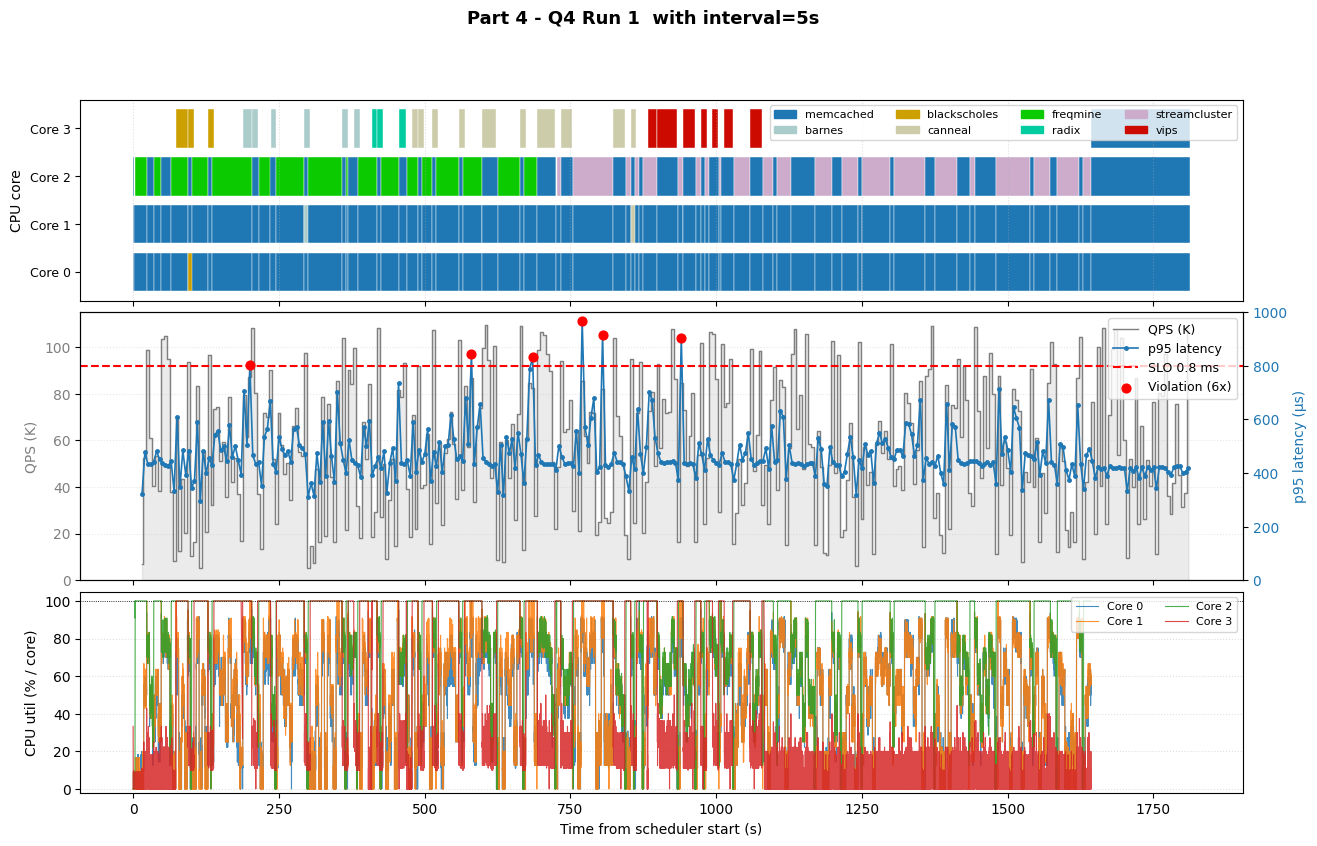

Run 1: 6/360 SLO violations (1.7%)
  max p95 = 967.1 µs  |  mean p95 = 469.2 µs
  CPU utilization per core:
    Core 0: mean= 50.7%  max=100.0%  std= 25.1%
    Core 1: mean= 52.7%  max=100.0%  std= 27.6%
    Core 2: mean= 86.6%  max=100.0%  std= 23.0%
    Core 3: mean= 46.1%  max=100.0%  std= 43.6%
    Total:  mean= 59.0%  max=100.0%  std= 34.9%
  -> saved: ../reports/figures/p4/q4/q4_run1.pdf



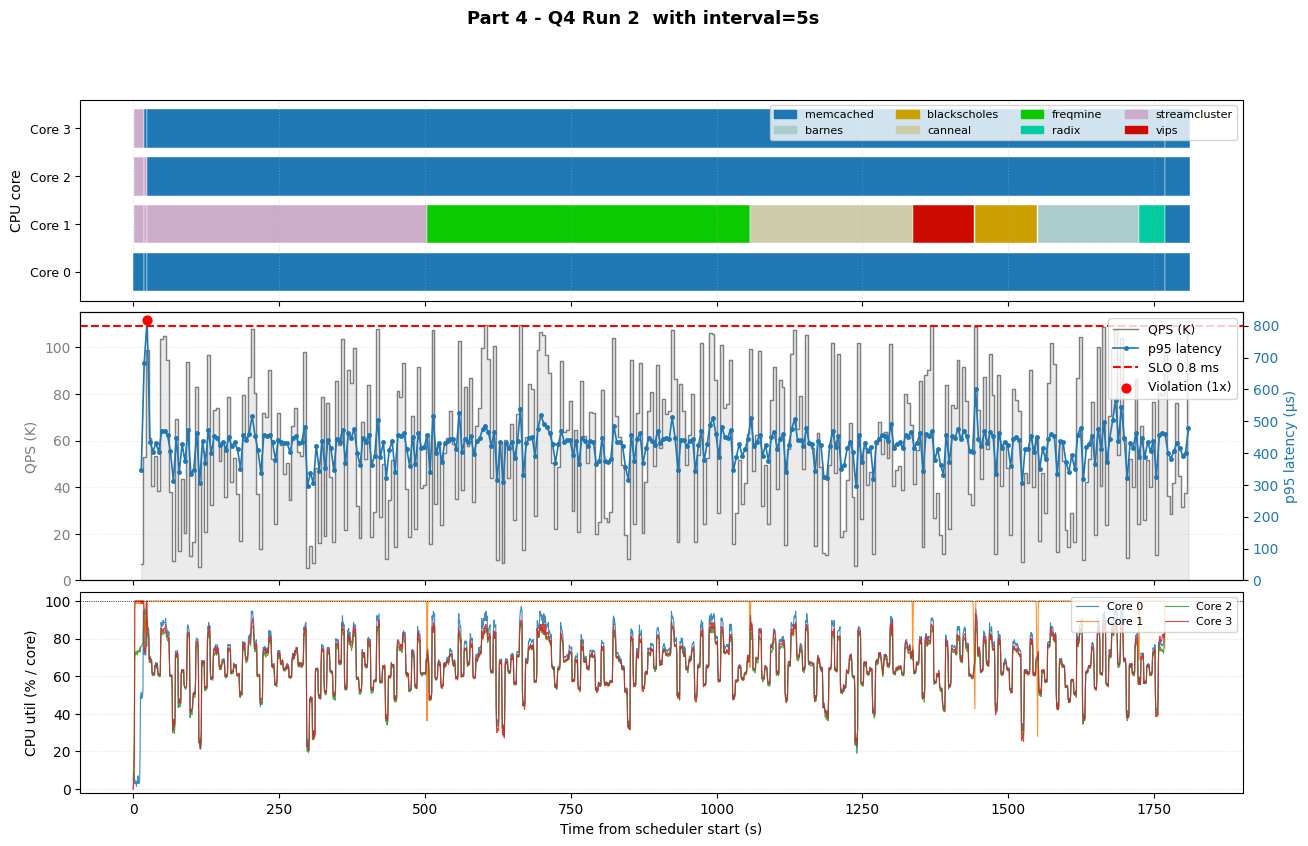

Run 2: 1/360 SLO violations (0.3%)
  max p95 = 816.7 µs  |  mean p95 = 425.3 µs
  CPU utilization per core:
    Core 0: mean= 67.4%  max= 98.7%  std= 14.6%
    Core 1: mean= 99.8%  max=100.0%  std=  3.7%
    Core 2: mean= 65.7%  max= 95.7%  std= 12.4%
    Core 3: mean= 66.7%  max=100.0%  std= 13.2%
    Total:  mean= 74.9%  max=100.0%  std= 18.6%
  -> saved: ../reports/figures/p4/q4/q4_run2.pdf



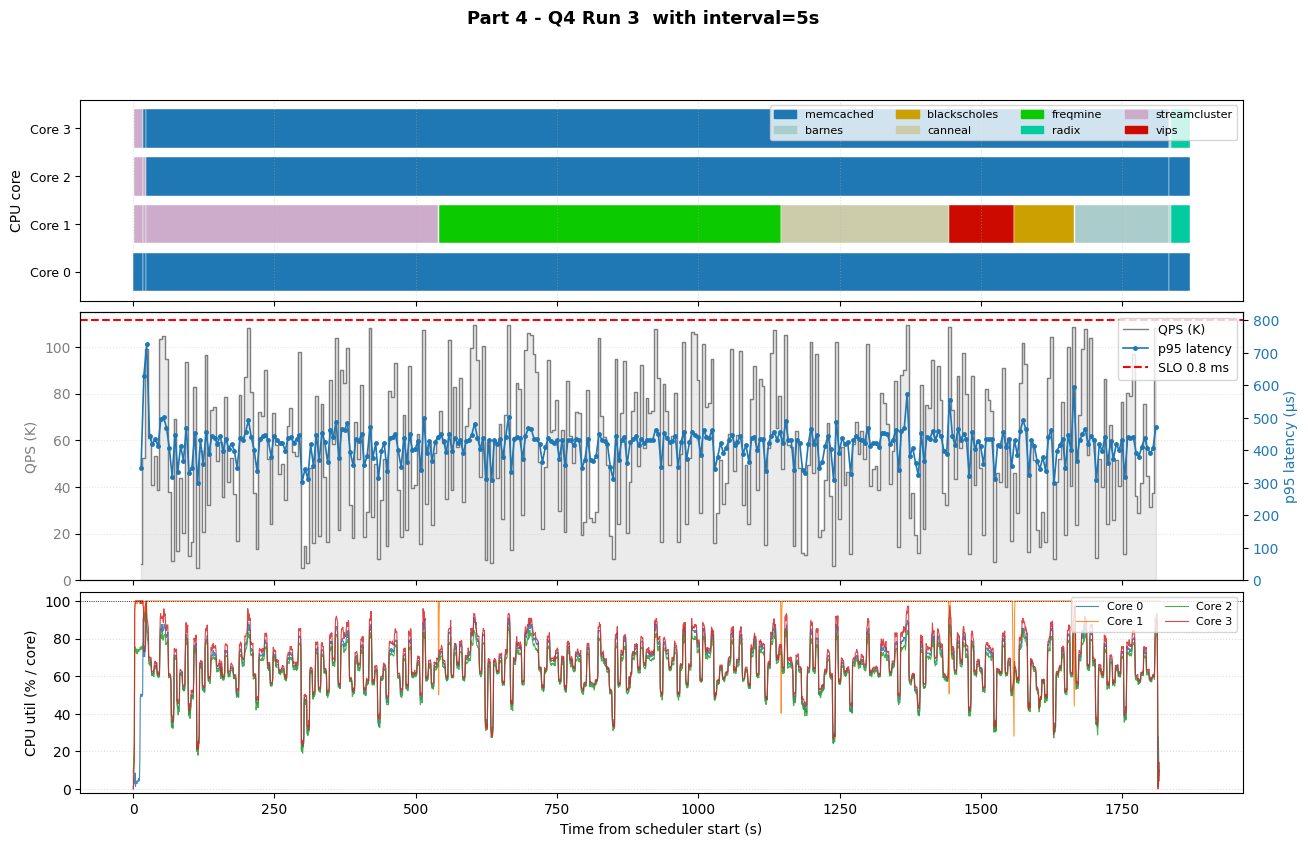

Run 3: 0/360 SLO violations (0.0%)
  max p95 = 725.7 µs  |  mean p95 = 417.2 µs
  CPU utilization per core:
    Core 0: mean= 65.3%  max= 98.7%  std= 13.3%
    Core 1: mean= 99.8%  max=100.0%  std=  3.5%
    Core 2: mean= 63.9%  max= 94.3%  std= 11.8%
    Core 3: mean= 67.9%  max=100.0%  std= 13.8%
    Total:  mean= 74.2%  max=100.0%  std= 18.7%
  -> saved: ../reports/figures/p4/q4/q4_run3.pdf



In [113]:
for run in RUNS:
    run_dir = Q4_DIR / f"run_{run}"
    if not run_dir.exists():
        print(f"Q4 run {run}: data not yet available ({run_dir})")
        continue
    plot_run(Q4_DIR, run, Q4_INTERVAL_S, label="Q4 ")

### Combined p95 overlay

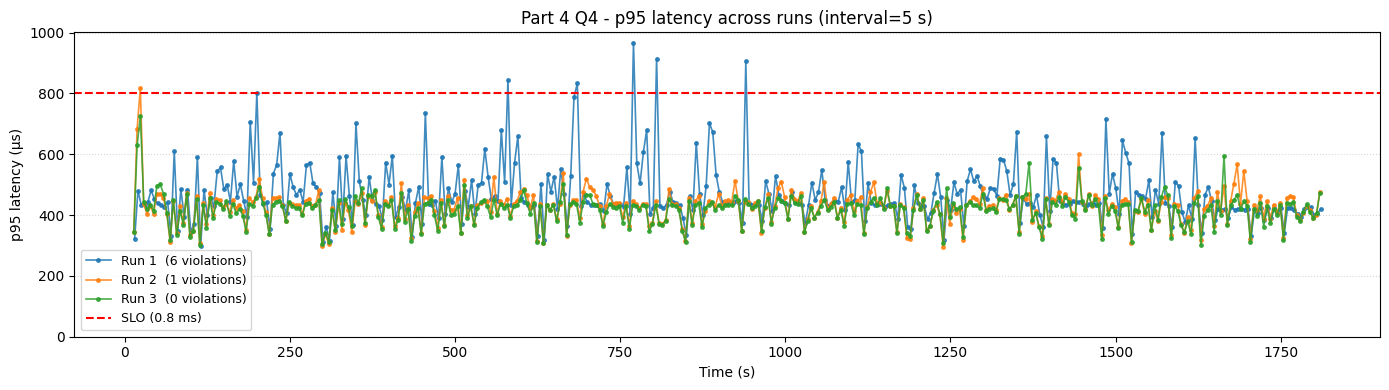

In [117]:
q4_runs_available = [r for r in RUNS if (Q4_DIR / f"run_{r}" / f"mcperf_{r}.txt").exists()]

if q4_runs_available:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors_runs = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for run, color in zip(q4_runs_available, colors_runs):
        unix_start, intervals = parse_mcperf(Q4_DIR / f"run_{run}" / f"mcperf_{run}.txt")
        sched_start, _ = parse_jobs(Q4_DIR / f"run_{run}" / f"jobs_{run}.txt")
        if sched_start is None:
            sched_start = datetime.fromtimestamp(unix_start, tz=timezone.utc)
        mcperf_offset = unix_start - sched_start.timestamp()
        t_mid = [mcperf_offset + (i + 0.5) * Q4_INTERVAL_S for i in range(len(intervals))]
        p95_us = [iv["p95"] for iv in intervals]
        n_viol = sum(1 for p in p95_us if p > SLO_US)
        ax.plot(t_mid, p95_us, marker="o", ms=2.5, lw=1.2, color=color, alpha=0.85,
                label=f"Run {run}  ({n_viol} violations)")
    ax.axhline(SLO_US, color="red", lw=1.5, ls="--", label=f"SLO ({SLO_MS} ms)")
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel("p95 latency (µs)", fontsize=10)
    ax.set_title("Part 4 Q4 - p95 latency across runs (interval=5 s)", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.savefig(FIG_Q4 / "q4_summary.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No Q4 runs available yet. Run 'make start-part-4-4 RUN=1/2/3' first.")

<a id='q4-sweep'></a>
## Q4

### Minimum `qps_interval`

Get what is the smallest `qps_interval` that keeps the SLO violation ratio under 3%.

Rather than guessing,
we run four intervals (4 s, 3 s, 2 s, 1 s) * 3 repetitions each
and measure the actual violation ratio empirically.
Data is collected with `make start-part-4-q4-sweep`,
or individually via `make start-part-4-int{N} RUN={1..3}`.

### Why 3 s is the expected threshold

The controller's end-to-end reaction chain has the following latencies:

| Step                                                      | Cost                |
|-----------------------------------------------------------|---------------------|
| CPU polling period `POLL_INTERVAL = 0.5 s`                | 0.5 s               |
| Expand trigger: `EXPAND_POLLS = 2` consecutive high reads | 1.0 s               |
| Docker `container.update(cpuset_cpus=)` syscall           | < 0.1 s             |
| Total reaction time                                       | $\approx$ 1.0–1.5 s |

If the load trace advances to the next QPS step every `qps_interval` seconds,
the controller has at most `qps_interval` seconds to detect the change
and reallocate cores before the following step arrives.

- 4 s: $\approx$ 2.5–3 s of slack after reaction, very safe.
- 3 s: $\approx$ 1.5–2 s of slack, should be sufficient for most transitions.
- 2 s: only $\approx$ 0.5–1 s of slack, marginal.
    A burst coinciding with a batch-job context switch can cause
    a violation burst before the controller catches up.
- 1 s: essentially no slack, the controller cannot detect
    and act on a load change before the next step arrives.
    Expected to produce frequent SLO violations.

The cells below verify which intervals actually pass the 3 % threshold empirically.

In [128]:
# Q4 interval sweep
# load data and compute SLO violation ratios for all intervals/runs.
# Requires:
# parse_mcperf, parse_jobs, job_durations_and_window, slo_violations_in_window
# (all defined in earlier cells).

SWEEP_INTERVALS = [4, 3, 2, 1]
SWEEP_DIRS = {
    4: Path("../data/p4/q4-int4"),
    3: Path("../data/p4/q4-int3"),
    2: Path("../data/p4/q4-int2"),
    1: Path("../data/p4/q4-int1"),
}

sweep_results = {}  # interval_s -> list of (run, viols, total, ratio)

for interval_s in SWEEP_INTERVALS:
    data_dir = SWEEP_DIRS[interval_s]
    results_for_interval = []
    print(f"interval = {interval_s}s  (data dir: {data_dir.name})")

    for run in RUNS:
        mcperf_path = data_dir / f"run_{run}" / f"mcperf_{run}.txt"
        jobs_path = data_dir / f"run_{run}" / f"jobs_{run}.txt"

        if not mcperf_path.exists():
            print(f"  run {run}: not yet available — "
                  f"run 'make start-part-4-int{interval_s} RUN={run}'")
            continue

        unix_start, intervals_data = parse_mcperf(mcperf_path)
        sched_start, events = parse_jobs(jobs_path)
        if sched_start is None:
            sched_start = datetime.fromtimestamp(unix_start, tz=timezone.utc)

        _, _, t0, t1 = job_durations_and_window(events)
        if t0 is None or t1 is None:
            # No batch jobs logged: fall back to full mcperf window
            t0 = datetime.fromtimestamp(unix_start, tz=timezone.utc)
            t1 = datetime.fromtimestamp(
                unix_start + len(intervals_data) * interval_s, tz=timezone.utc)

        viols, total = slo_violations_in_window(data_dir, run, interval_s, t0, t1)
        ratio = viols / total if total > 0 else 0.0
        results_for_interval.append((run, viols, total, ratio))
        print(f"  run {run}: {viols}/{total} violations ({100 * ratio:.2f}%)")

    sweep_results[interval_s] = results_for_interval
    if results_for_interval:
        all_r = [r[3] for r in results_for_interval]
        print(f"  -> mean violation ratio: {100 * np.mean(all_r):.2f}%")
    print()

interval = 4s  (data dir: q4-int4)
  run 1: 3/446 violations (0.67%)
  run 2: 0/402 violations (0.00%)
  run 3: 0/403 violations (0.00%)
  -> mean violation ratio: 0.22%

interval = 3s  (data dir: q4-int3)
  run 1: 10/591 violations (1.69%)
  run 2: 0/594 violations (0.00%)
  run 3: 0/564 violations (0.00%)
  -> mean violation ratio: 0.56%

interval = 2s  (data dir: q4-int2)
  run 1: 16/900 violations (1.78%)
  run 2: 1/828 violations (0.12%)
  run 3: 1/830 violations (0.12%)
  -> mean violation ratio: 0.67%

interval = 1s  (data dir: q4-int1)
  run 1: 37/1800 violations (2.06%)
  run 2: 3/1703 violations (0.18%)
  run 3: 3/1625 violations (0.18%)
  -> mean violation ratio: 0.81%



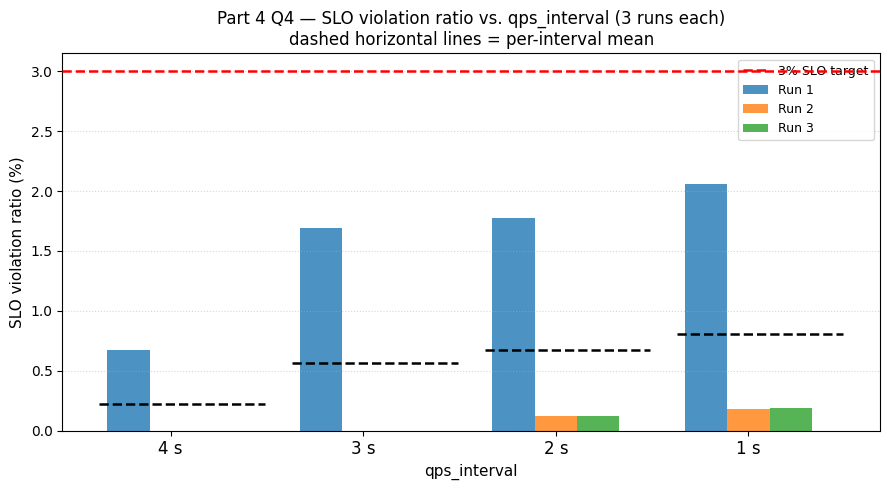


  Interval    Run1 (%)    Run2 (%)    Run3 (%)    Mean (%)    < 3%?
----------------------------------------------------------------------
       4s         0.67        0.00        0.00        0.22      YES
       3s         1.69        0.00        0.00        0.56      YES
       2s         1.78        0.12        0.12        0.67      YES
       1s         2.06        0.18        0.18        0.81      YES


In [129]:
# Bar chart + summary table: SLO violation ratio vs qps_interval
intervals_available = [iv for iv in SWEEP_INTERVALS if sweep_results.get(iv)]
if not intervals_available:
    print("No sweep data yet, run: make start-part-4-q4-sweep")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.22
    x = np.arange(len(intervals_available))
    run_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    mean_ratios = []
    for ivx, interval_s in enumerate(intervals_available):
        run_ratios = []
        for run_idx, run in enumerate(RUNS):
            run_data = [r for r in sweep_results[interval_s] if r[0] == run]
            ratio_pct = run_data[0][3] * 100 if run_data else np.nan
            run_ratios.append(ratio_pct)
            if not np.isnan(ratio_pct):
                ax.bar(ivx + run_idx * bar_width, ratio_pct, bar_width,
                       color=run_colors[run_idx], alpha=0.8,
                       label=f"Run {run}" if ivx == 0 else "")
        valid = [r for r in run_ratios if not np.isnan(r)]
        mean_ratios.append(np.mean(valid) if valid else np.nan)

    # Mean marker per interval
    for ivx, mr in enumerate(mean_ratios):
        if not np.isnan(mr):
            ax.hlines(mr, ivx - 0.15, ivx + len(RUNS) * bar_width + 0.05,
                      colors="black", lw=1.8, ls="--", zorder=5)

    ax.axhline(3.0, color="red", lw=1.8, ls="--", label="3% SLO target", zorder=6)
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f"{iv} s" for iv in intervals_available], fontsize=12)
    ax.set_xlabel("qps_interval", fontsize=11)
    ax.set_ylabel("SLO violation ratio (%)", fontsize=11)
    ax.set_title(
        "Part 4 Q4 — SLO violation ratio vs. qps_interval (3 runs each)\n"
        "dashed horizontal lines = per-interval mean",
        fontsize=12)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.savefig(FIG_Q4 / "q4_interval_sweep.pdf", bbox_inches="tight")
    plt.show()

    # Summary table
    print(f"\n{'Interval':>10}  {'Run1 (%)':>10}  {'Run2 (%)':>10}  {'Run3 (%)':>10}  "
          f"{'Mean (%)':>10}  {'< 3%?':>7}")
    print("-" * 70)
    for interval_s, mr in zip(intervals_available, mean_ratios):
        row = []
        for run in RUNS:
            run_data = [r for r in sweep_results[interval_s] if r[0] == run]
            row.append(run_data[0][3] * 100 if run_data else float("nan"))
        ok = "YES" if (not np.isnan(mr) and mr < 3.0) else "NO"
        cols = "  ".join(f"{v:>10.2f}" for v in row)
        print(f"{interval_s:>8}s   {cols}  {mr:>10.2f}  {ok:>7}")

### Smallest valid `qps_interval`

Examine the summary table printed by the cell above,
to find the smallest `qps_interval` for which the mean SLO violation ratio
stays below 3%.

Set `Q4_MIN_INTERVAL` in the next cell to that value,
then re-run the remaining two cells to produce the per-run three-panel plots
and the job runtime table required.

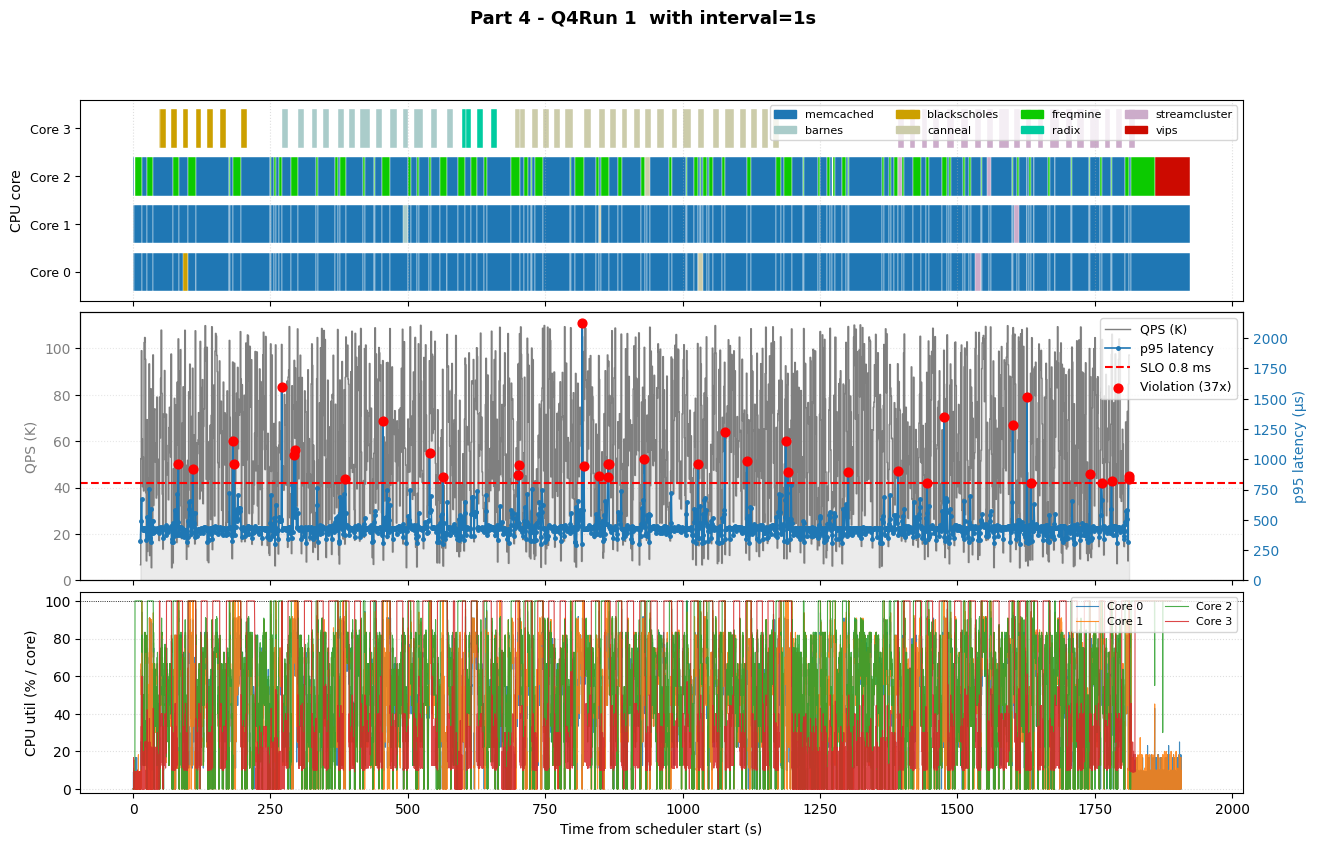

Run 1: 37/1800 SLO violations (2.1%)
  max p95 = 2124.1 µs  |  mean p95 = 448.7 µs
  CPU utilization per core:
    Core 0: mean= 45.0%  max=100.0%  std= 26.5%
    Core 1: mean= 45.2%  max=100.0%  std= 28.4%
    Core 2: mean= 62.8%  max=100.0%  std= 32.8%
    Core 3: mean= 55.0%  max=100.0%  std= 41.7%
    Total:  mean= 52.0%  max=100.0%  std= 33.7%
  -> saved: ../reports/figures/p4/q4/q4_int1_run1.pdf



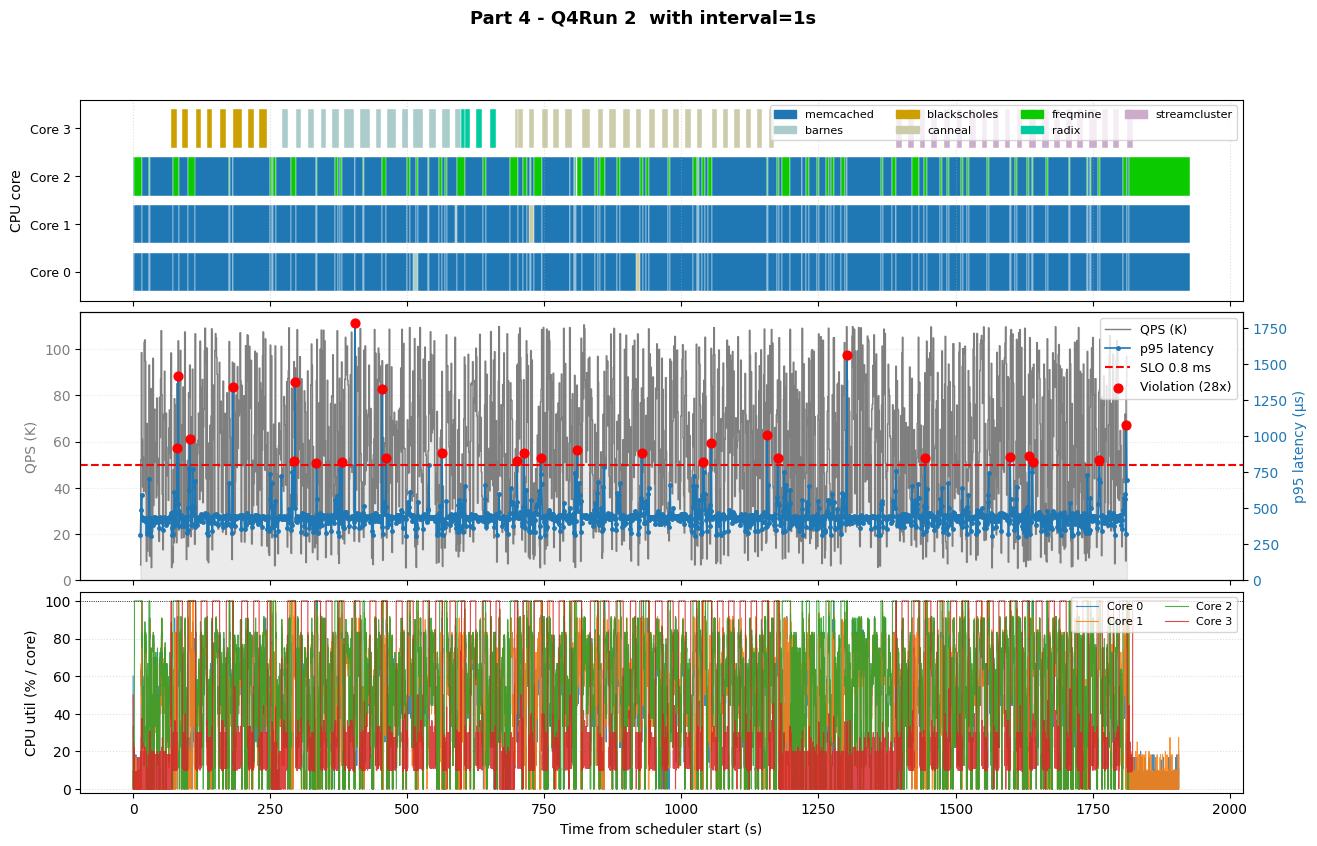

Run 2: 28/1800 SLO violations (1.6%)
  max p95 = 1784.0 µs  |  mean p95 = 448.3 µs
  CPU utilization per core:
    Core 0: mean= 45.8%  max=100.0%  std= 26.9%
    Core 1: mean= 46.4%  max=100.0%  std= 28.4%
    Core 2: mean= 61.0%  max=100.0%  std= 32.1%
    Core 3: mean= 51.4%  max=100.0%  std= 42.7%
    Total:  mean= 51.2%  max=100.0%  std= 33.7%
  -> saved: ../reports/figures/p4/q4/q4_int1_run2.pdf



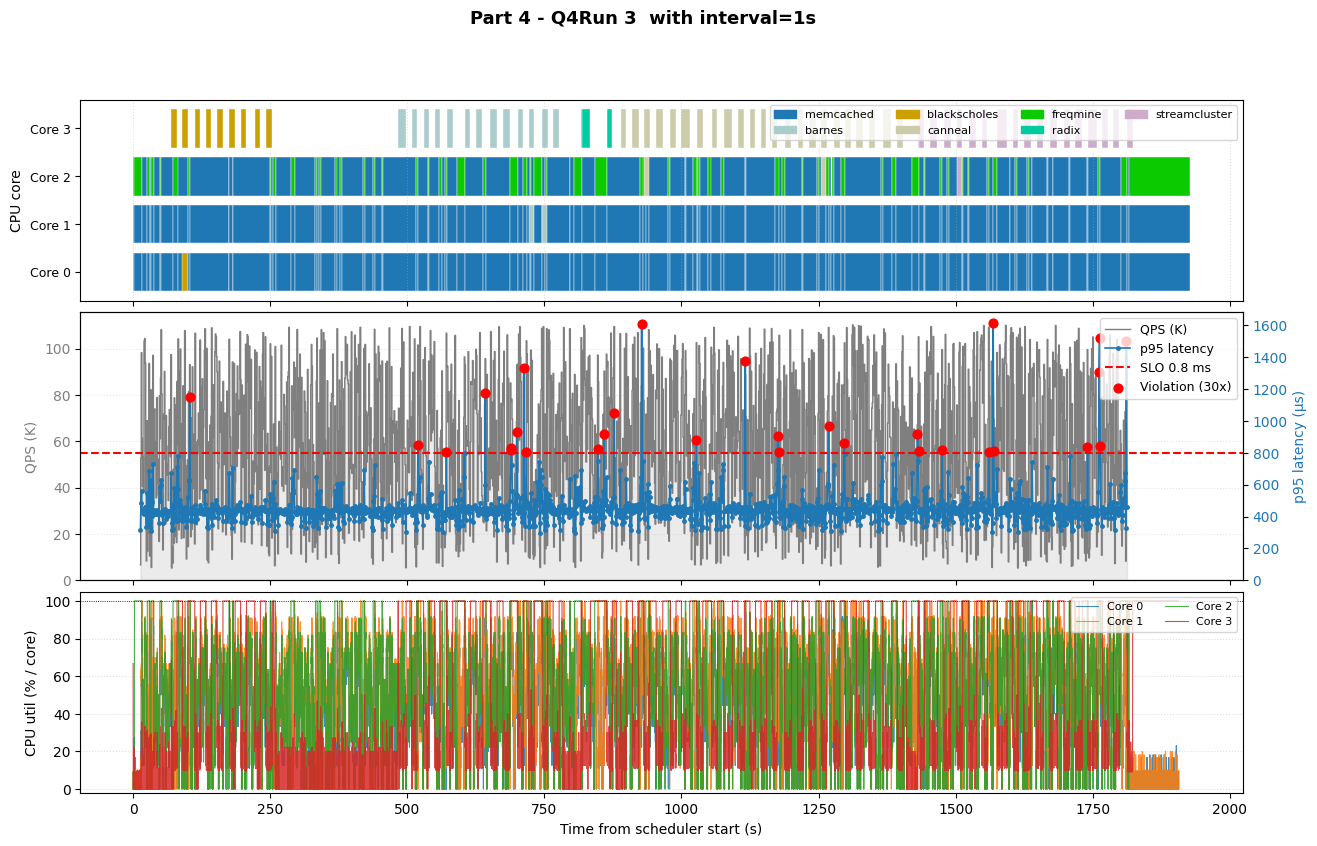

Run 3: 30/1800 SLO violations (1.7%)
  max p95 = 1616.2 µs  |  mean p95 = 454.9 µs
  CPU utilization per core:
    Core 0: mean= 42.1%  max=100.0%  std= 24.7%
    Core 1: mean= 49.7%  max=100.0%  std= 30.0%
    Core 2: mean= 60.0%  max=100.0%  std= 31.9%
    Core 3: mean= 51.4%  max=100.0%  std= 42.4%
    Total:  mean= 50.8%  max=100.0%  std= 33.5%
  -> saved: ../reports/figures/p4/q4/q4_int1_run3.pdf



In [131]:
# Per-run plots for the minimum viable qps_interval.
# Set Q4_MIN_INTERVAL to the value identified by the sweep analysis above.
Q4_MIN_INTERVAL = 1  # seconds

min_int_dir = SWEEP_DIRS.get(Q4_MIN_INTERVAL)
if min_int_dir is None or not any(
        (min_int_dir / f"run_{r}" / f"mcperf_{r}.txt").exists() for r in RUNS):
    print(f"No data for interval={Q4_MIN_INTERVAL}s - "
          f"run: make start-part-4-int{Q4_MIN_INTERVAL} RUN={{1,2,3}}")
else:
    for run in RUNS:
        run_dir = min_int_dir / f"run_{run}"
        if not (run_dir / f"mcperf_{run}.txt").exists():
            print(f"  Run {run}: data not yet available")
            continue
        plot_run(min_int_dir, run, Q4_MIN_INTERVAL,
                 label=f"Q4") #  (interval={Q4_MIN_INTERVAL}s) ")

In [132]:
# Job runtimes table for the minimum viable qps_interval
# (Q4_MIN_INTERVAL must be set in the plots cell above before running this cell)

min_int_dir = SWEEP_DIRS.get(Q4_MIN_INTERVAL)
available_runs = [
    r for r in RUNS
    if min_int_dir is not None
       and (min_int_dir / f"run_{r}" / f"jobs_{r}.txt").exists()
]

if not available_runs:
    print(f"No jobs data for interval={Q4_MIN_INTERVAL}s - collect data first.")
else:
    q4min_durations = {job: [] for job in JOBS_REPORT_ORDER}
    q4min_makespans = []

    for run in available_runs:
        jobs_path = min_int_dir / f"run_{run}" / f"jobs_{run}.txt"
        _, events = parse_jobs(jobs_path)
        durs, ms, t0, t1 = job_durations_and_window(events)
        if ms is None:
            continue
        q4min_makespans.append(ms)
        for job in JOBS_REPORT_ORDER:
            q4min_durations[job].append(durs.get(job, float("nan")))

    n_runs = len(q4min_makespans)
    print(f"Job runtimes for qps_interval={Q4_MIN_INTERVAL}s "
          f"(mean and std across {n_runs} run(s)):")
    print()
    print(f"{'Job':<16} {'Mean [s]':>10} {'Std [s]':>10}")
    print("-" * 38)
    for job in sorted(JOBS_REPORT_ORDER):
        vals = [v for v in q4min_durations[job] if not np.isnan(v)]
        mean = statistics.mean(vals) if vals else float("nan")
        std = statistics.stdev(vals) if len(vals) > 1 else 0.0
        print(f"{job:<16} {mean:>10.1f} {std:>10.1f}")
    print("-" * 38)
    ms_mean = statistics.mean(q4min_makespans) if q4min_makespans else float("nan")
    ms_std = statistics.stdev(q4min_makespans) if len(q4min_makespans) > 1 else 0.0
    print(f"{'total time':<16} {ms_mean:>10.1f} {ms_std:>10.1f}")

Job runtimes for qps_interval=1s (mean and std across 3 run(s)):

Job                Mean [s]    Std [s]
--------------------------------------
barnes                313.6       13.8
blackscholes          182.2        6.9
canneal               501.8       19.5
freqmine             1901.8       40.2
radix                  68.9        3.8
streamcluster         513.3       23.8
vips                   64.1        0.0
--------------------------------------
total time           1923.3        3.0


<a id='search'></a>
## Controller-policy search

Comparison of four batch-scheduling policies for the redesigned 2-slot controller,
selected via the `CONTROLLER_POLICY` env var (see `scripts/controller.py`).
Static reservation: core 0 -> memcached, core 3 -> batch slot_A.
Cores [1, 2] are dynamic.

| Policy        | expand thr. | shrink thr. | dwell  | init tier | cap tier | description                                                  |
|---------------|-------------|-------------|--------|-----------|----------|--------------------------------------------------------------|
| `static`      | --          | --          | --     | 2 locked  | 2        | parallelism baseline (no dynamic scaling)                    |
| `responsive`  | > 75 %      | < 30 %      | 1.5 s  | 1         | 3        | balanced default; pauses slot_B in tier 3                    |
| `aggressive`  | > 60 %      | < 40 %      | 0.5 s  | 1         | 3        | fast reactions, allows tier 3                                |
| `throughput`  | > 85 %      | < 50 %      | 0.5 s  | 1         | **2**    | batch-first: never pauses slot_B, snaps memcached back fast  |

Each policy is run once for 5 minutes with `qps_interval = 15 s`
(same load trace seed as Q3) to enable rapid iteration.
Reference baselines: legacy Q3 makespan ~ **1725 s**, target ≤ **900 s**.

Data collection:
`make start-search/all`
(or per policy: `make start-search/<policy>`).

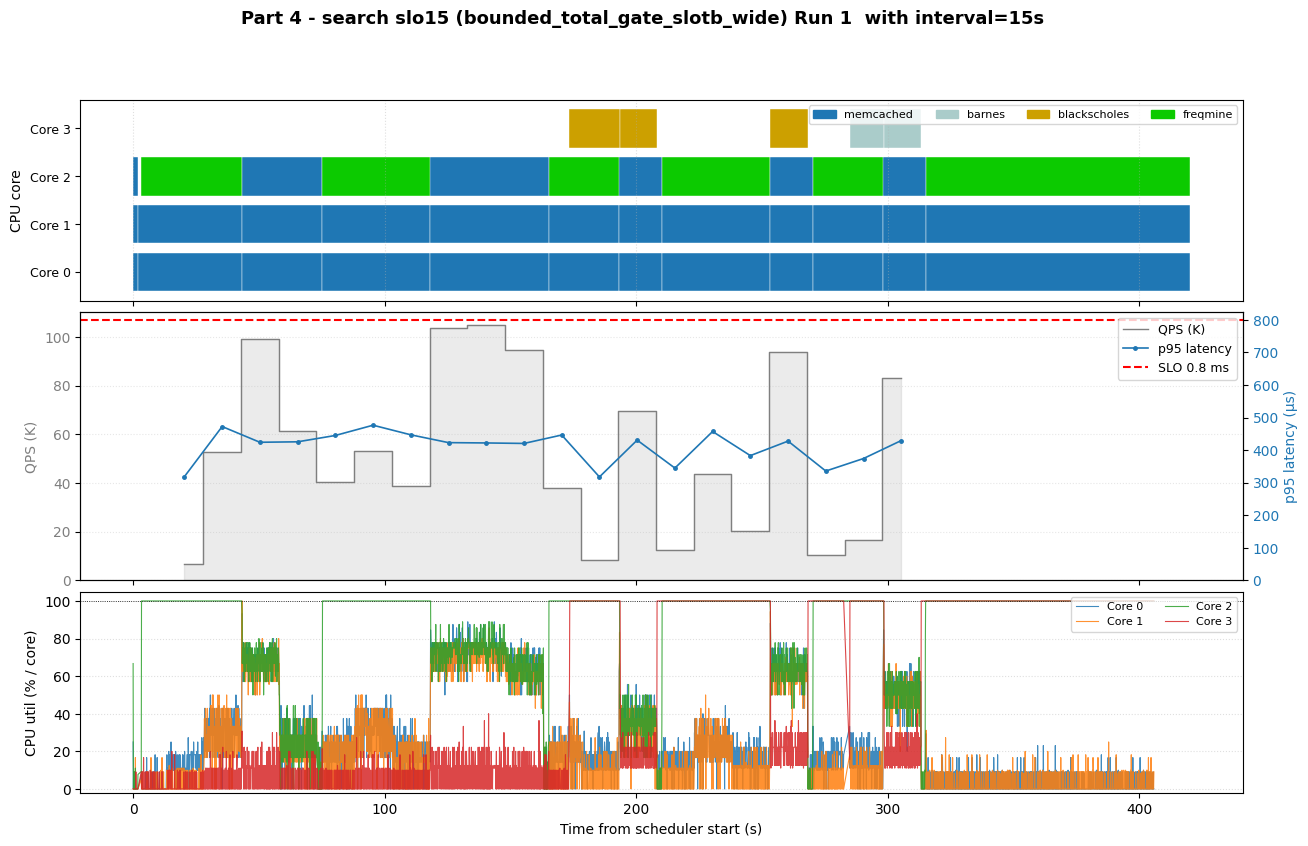

Run 1: 0/20 SLO violations (0.0%)
  max p95 = 476.6 µs  |  mean p95 = 411.2 µs
  CPU utilization per core:
    Core 0: mean= 25.8%  max= 93.3%  std= 24.4%
    Core 1: mean= 22.3%  max=100.0%  std= 24.8%
    Core 2: mean= 84.6%  max=100.0%  std= 26.0%
    Core 3: mean= 50.5%  max=100.0%  std= 46.2%
    Total:  mean= 45.8%  max=100.0%  std= 40.3%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_wide_run1.pdf



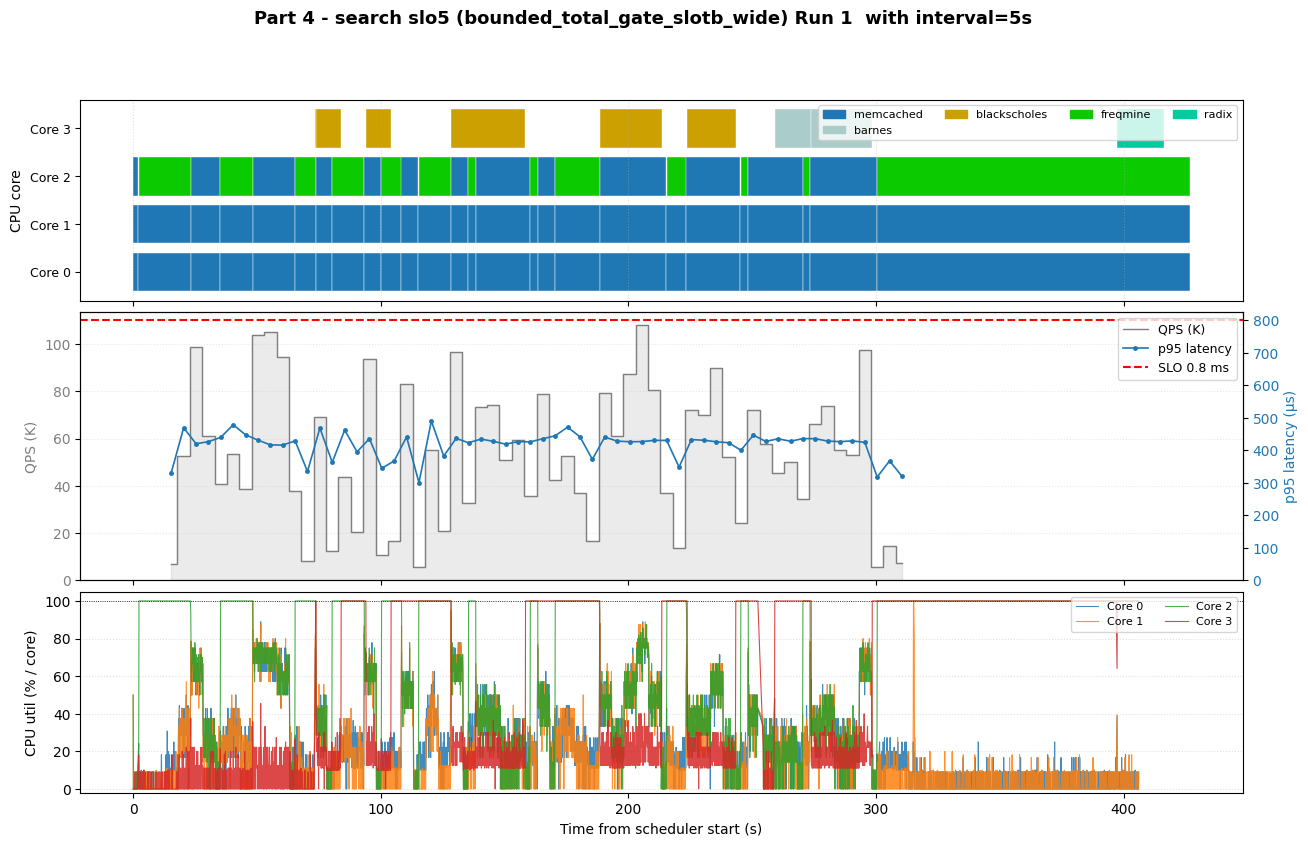

Run 1: 0/60 SLO violations (0.0%)
  max p95 = 490.1 µs  |  mean p95 = 416.9 µs
  CPU utilization per core:
    Core 0: mean= 23.7%  max= 88.9%  std= 21.6%
    Core 1: mean= 21.3%  max=100.0%  std= 22.8%
    Core 2: mean= 71.1%  max=100.0%  std= 35.4%
    Core 3: mean= 57.5%  max=100.0%  std= 44.0%
    Total:  mean= 43.4%  max=100.0%  std= 38.8%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_wide_run1.pdf



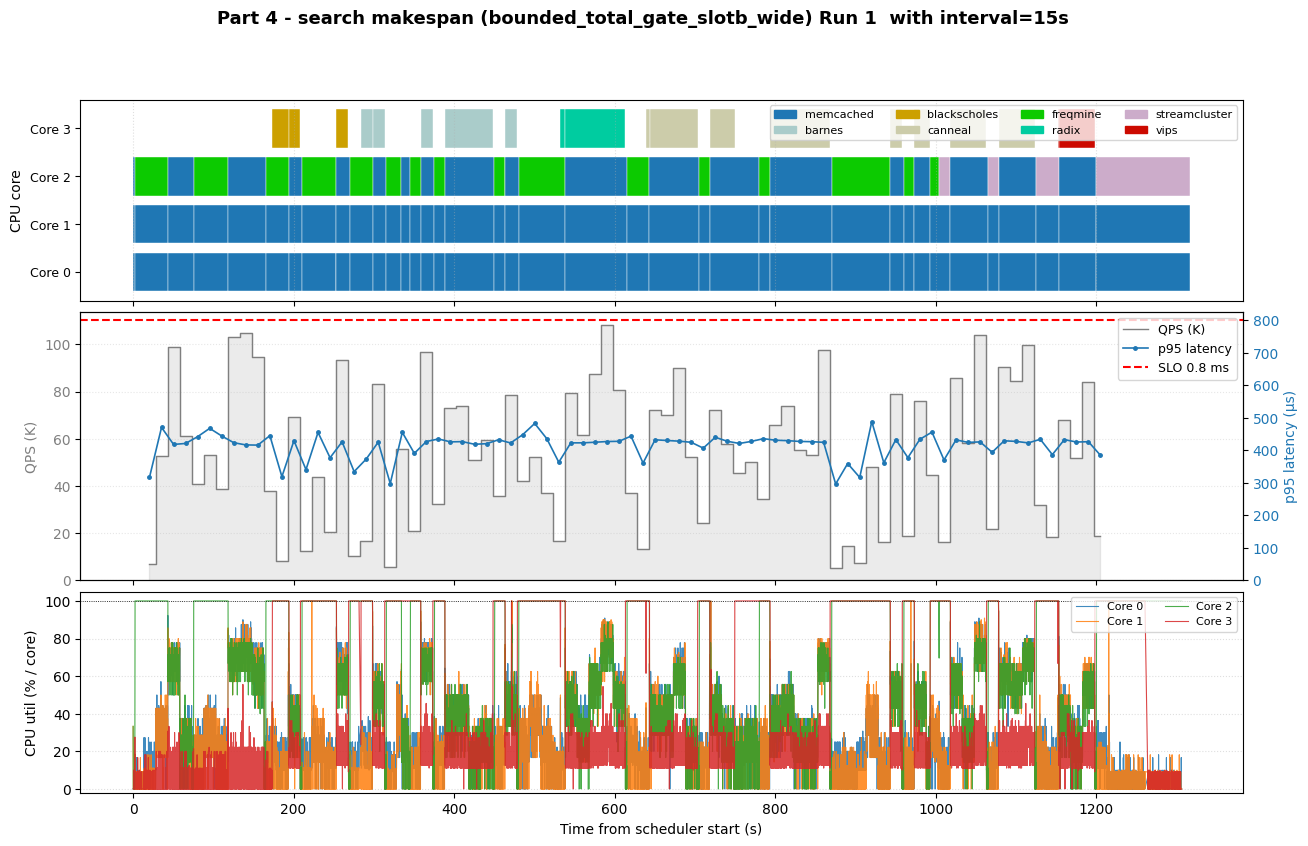

Run 1: 0/80 SLO violations (0.0%)
  max p95 = 488.4 µs  |  mean p95 = 414.1 µs
  CPU utilization per core:
    Core 0: mean= 31.3%  max=100.0%  std= 22.3%
    Core 1: mean= 28.5%  max=100.0%  std= 23.9%
    Core 2: mean= 68.8%  max=100.0%  std= 33.0%
    Core 3: mean= 50.7%  max=100.0%  std= 42.2%
    Total:  mean= 44.8%  max=100.0%  std= 35.3%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_wide_run1.pdf



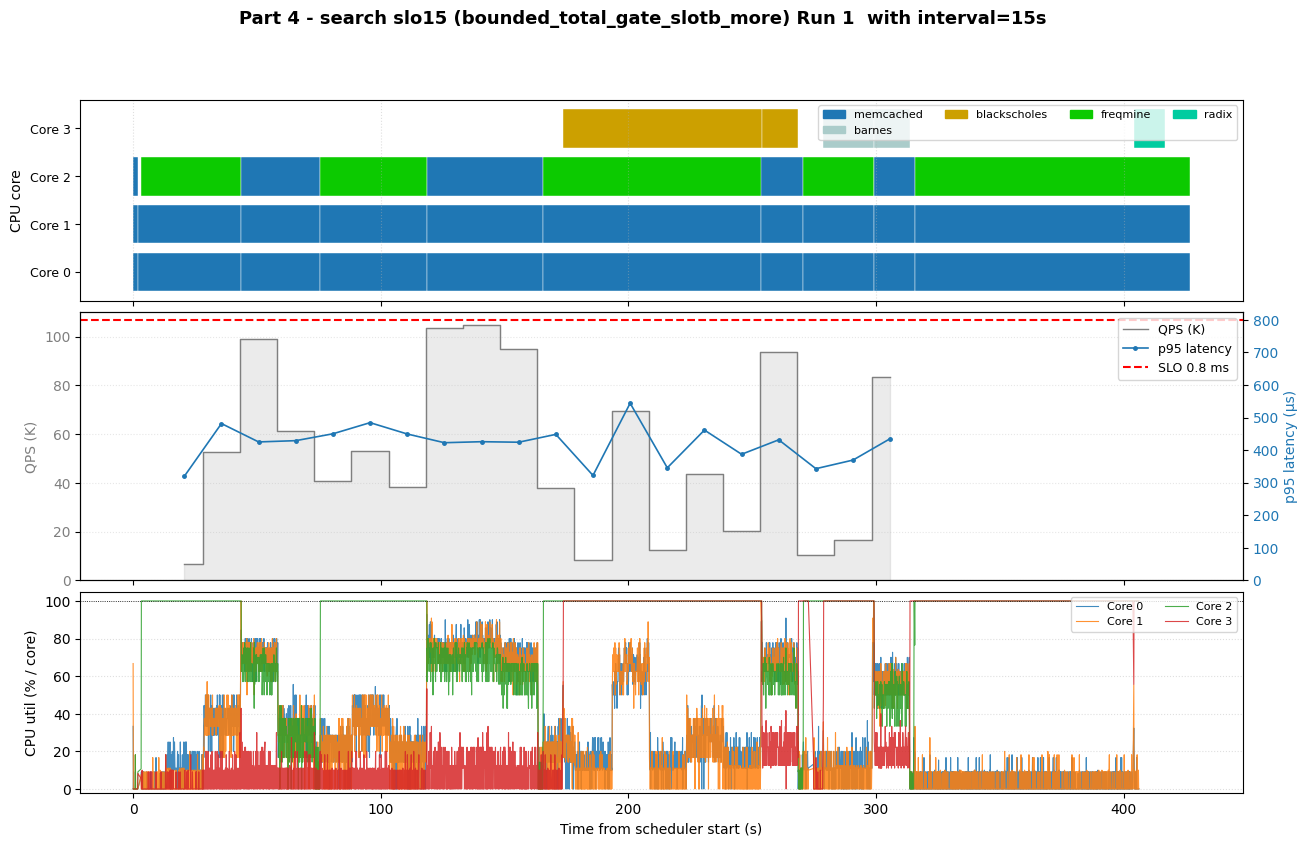

Run 1: 0/20 SLO violations (0.0%)
  max p95 = 544.1 µs  |  mean p95 = 420.1 µs
  CPU utilization per core:
    Core 0: mean= 28.9%  max= 92.9%  std= 27.0%
    Core 1: mean= 26.1%  max=100.0%  std= 27.9%
    Core 2: mean= 86.4%  max=100.0%  std= 24.2%
    Core 3: mean= 52.9%  max=100.0%  std= 46.4%
    Total:  mean= 48.6%  max=100.0%  std= 40.6%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_more_run1.pdf



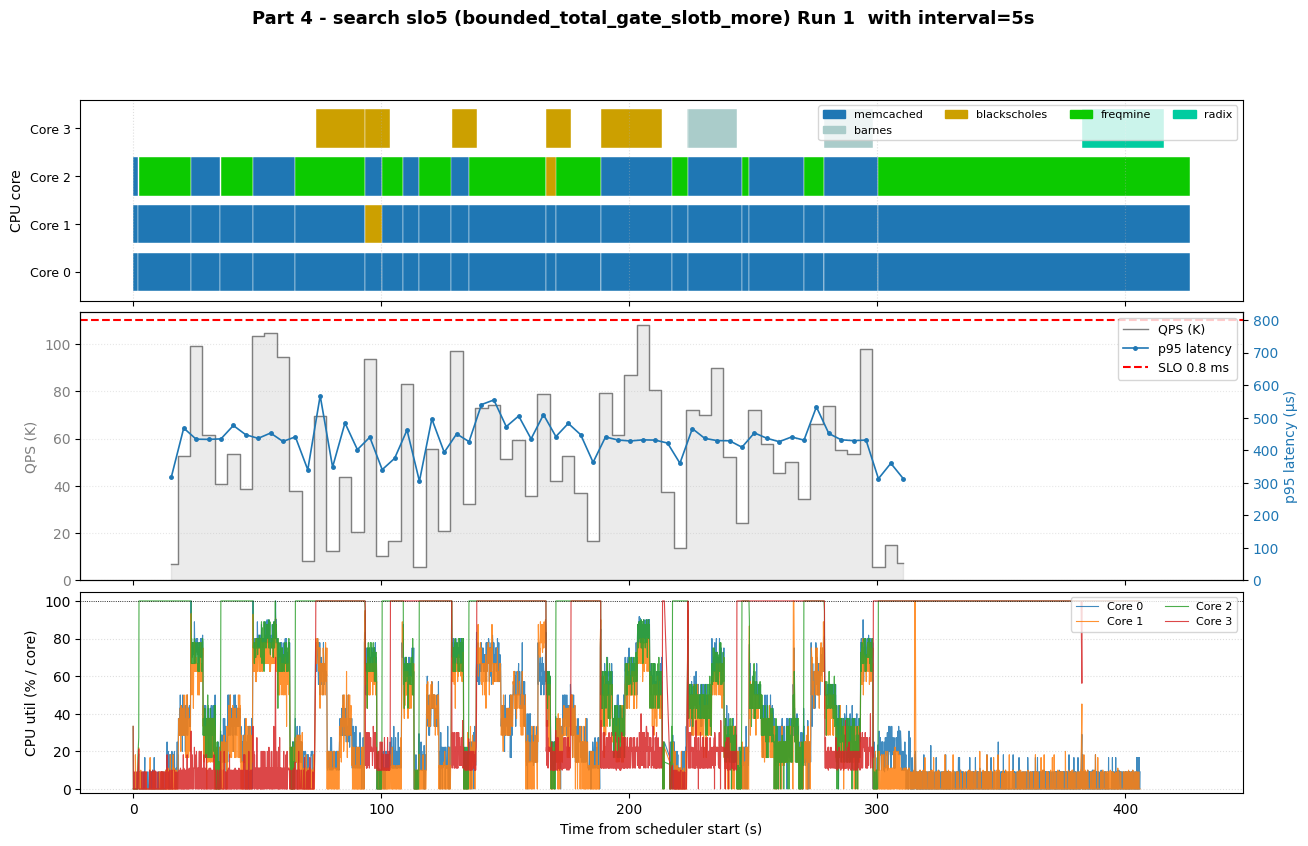

Run 1: 0/60 SLO violations (0.0%)
  max p95 = 567.5 µs  |  mean p95 = 432.0 µs
  CPU utilization per core:
    Core 0: mean= 29.5%  max=100.0%  std= 26.0%
    Core 1: mean= 24.6%  max=100.0%  std= 25.0%
    Core 2: mean= 80.0%  max=100.0%  std= 30.6%
    Core 3: mean= 61.7%  max=100.0%  std= 44.2%
    Total:  mean= 48.9%  max=100.0%  std= 39.6%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_more_run1.pdf



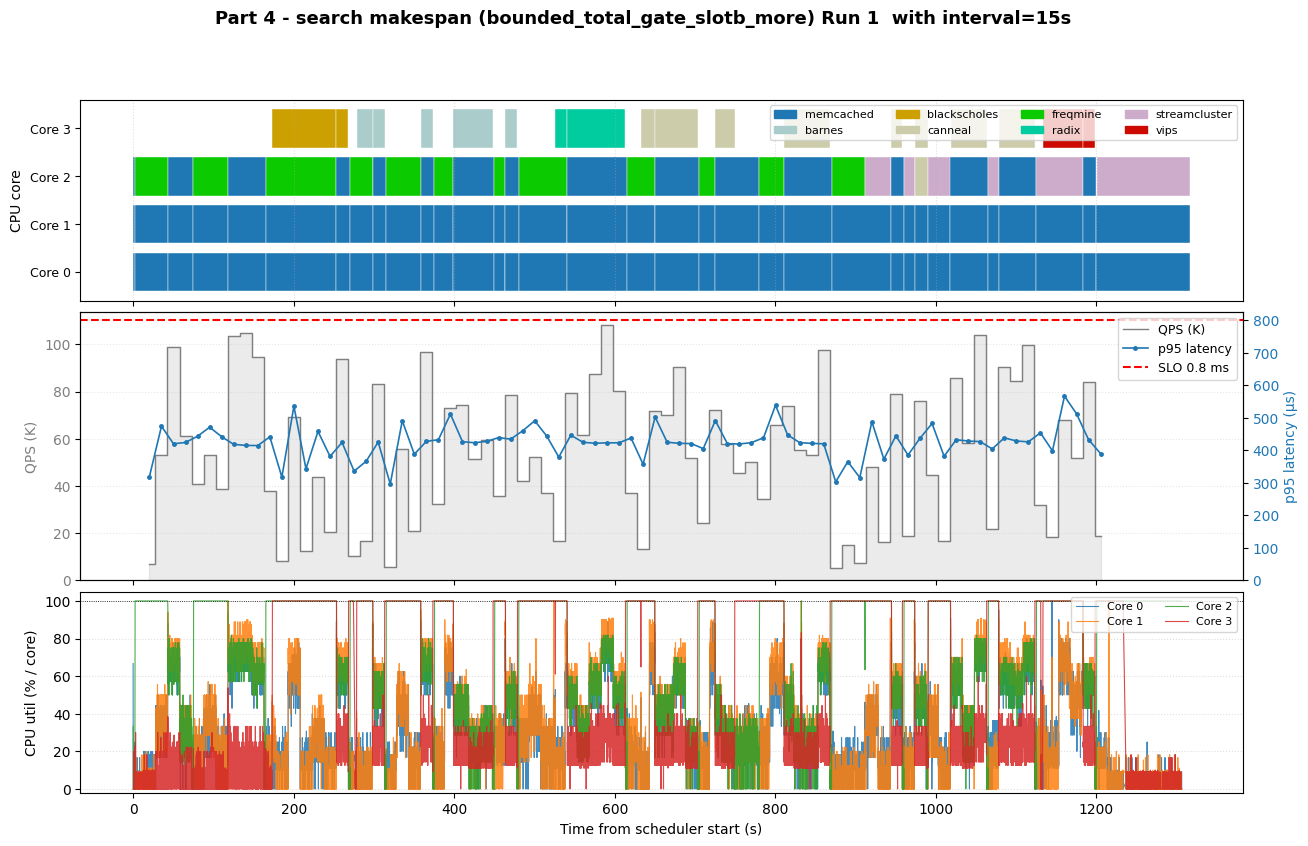

Run 1: 0/80 SLO violations (0.0%)
  max p95 = 566.7 µs  |  mean p95 = 425.1 µs
  CPU utilization per core:
    Core 0: mean= 32.6%  max=100.0%  std= 22.2%
    Core 1: mean= 34.0%  max=100.0%  std= 26.5%
    Core 2: mean= 75.3%  max=100.0%  std= 30.7%
    Core 3: mean= 55.1%  max=100.0%  std= 42.5%
    Total:  mean= 49.2%  max=100.0%  std= 35.9%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_more_run1.pdf



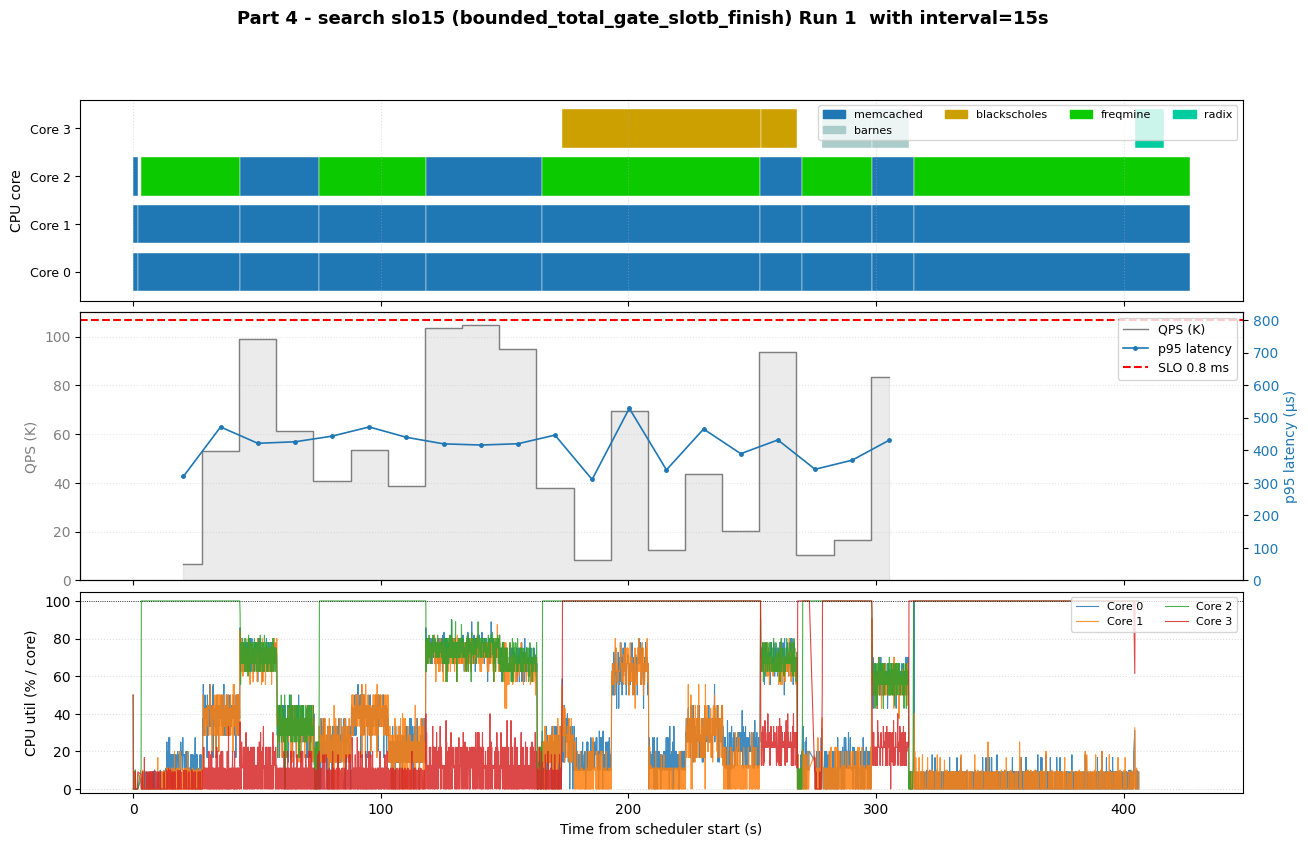

Run 1: 0/20 SLO violations (0.0%)
  max p95 = 528.8 µs  |  mean p95 = 415.0 µs
  CPU utilization per core:
    Core 0: mean= 29.3%  max=100.0%  std= 26.4%
    Core 1: mean= 26.7%  max=100.0%  std= 27.0%
    Core 2: mean= 88.4%  max=100.0%  std= 21.7%
    Core 3: mean= 53.5%  max=100.0%  std= 46.0%
    Total:  mean= 49.5%  max=100.0%  std= 40.2%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_finish_run1.pdf



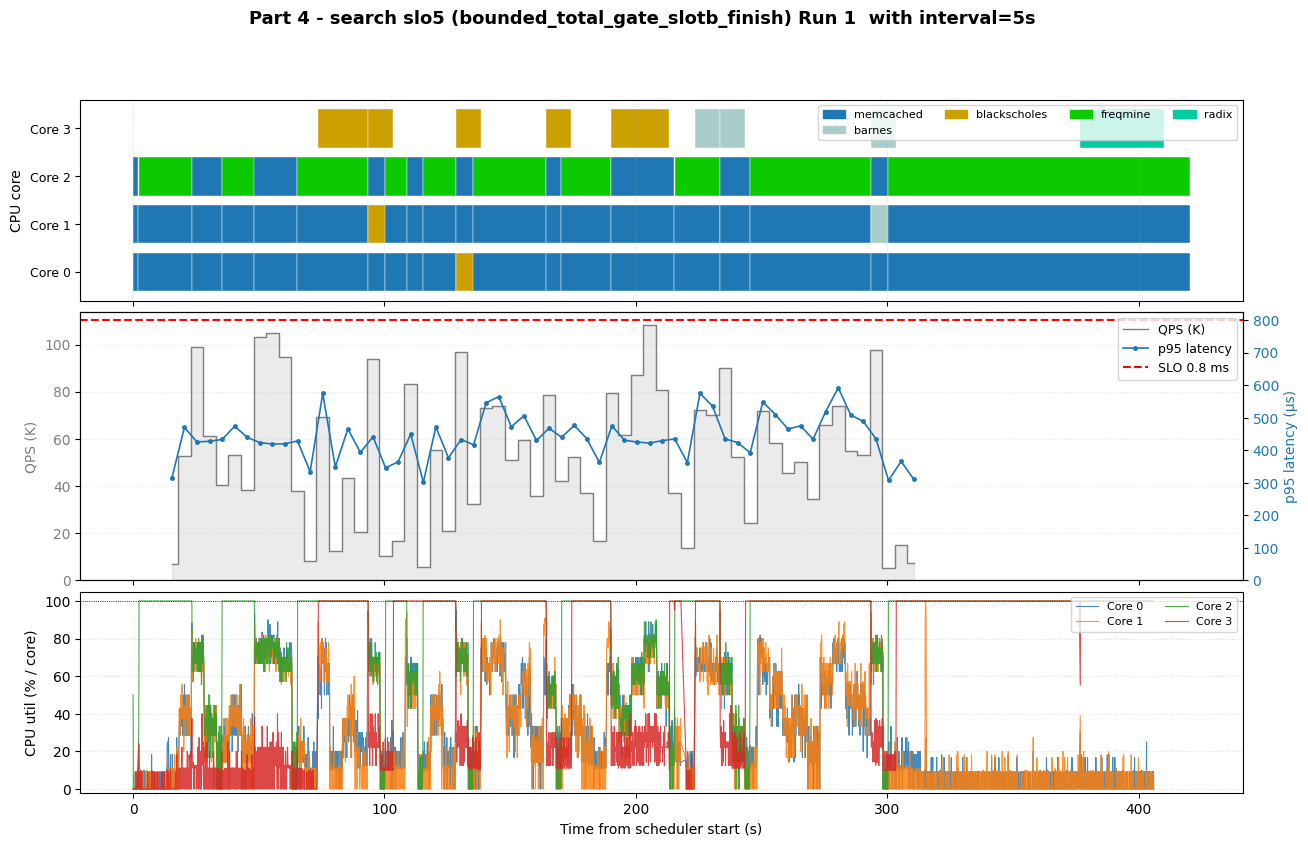

Run 1: 0/60 SLO violations (0.0%)
  max p95 = 592.2 µs  |  mean p95 = 440.0 µs
  CPU utilization per core:
    Core 0: mean= 30.3%  max= 95.2%  std= 26.4%
    Core 1: mean= 28.9%  max=100.0%  std= 27.7%
    Core 2: mean= 87.2%  max=100.0%  std= 25.6%
    Core 3: mean= 67.5%  max=100.0%  std= 42.6%
    Total:  mean= 53.5%  max=100.0%  std= 40.0%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_finish_run1.pdf



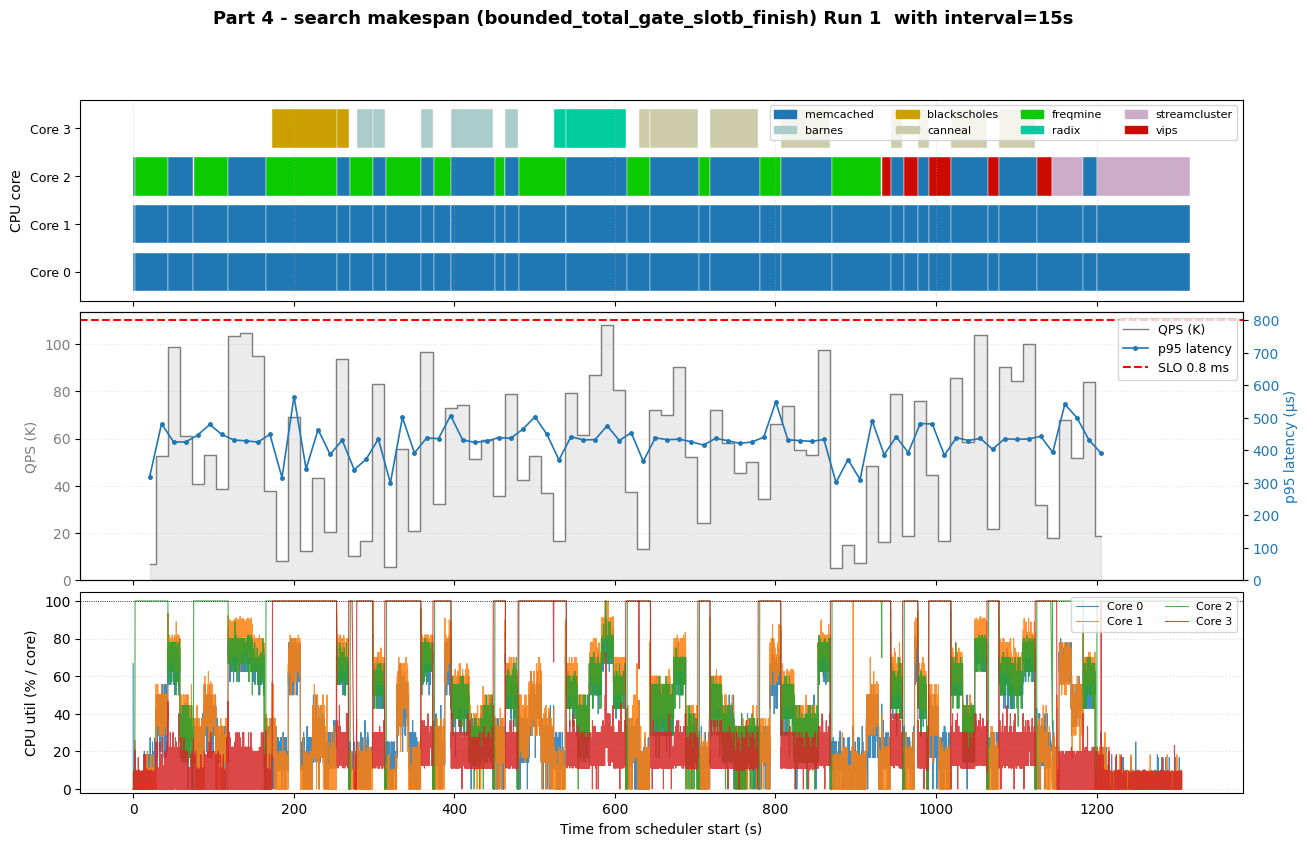

Run 1: 0/80 SLO violations (0.0%)
  max p95 = 565.1 µs  |  mean p95 = 428.7 µs
  CPU utilization per core:
    Core 0: mean= 33.8%  max=100.0%  std= 23.0%
    Core 1: mean= 36.1%  max=100.0%  std= 27.6%
    Core 2: mean= 75.6%  max=100.0%  std= 29.7%
    Core 3: mean= 45.6%  max=100.0%  std= 42.5%
    Total:  mean= 47.8%  max=100.0%  std= 35.7%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_finish_run1.pdf



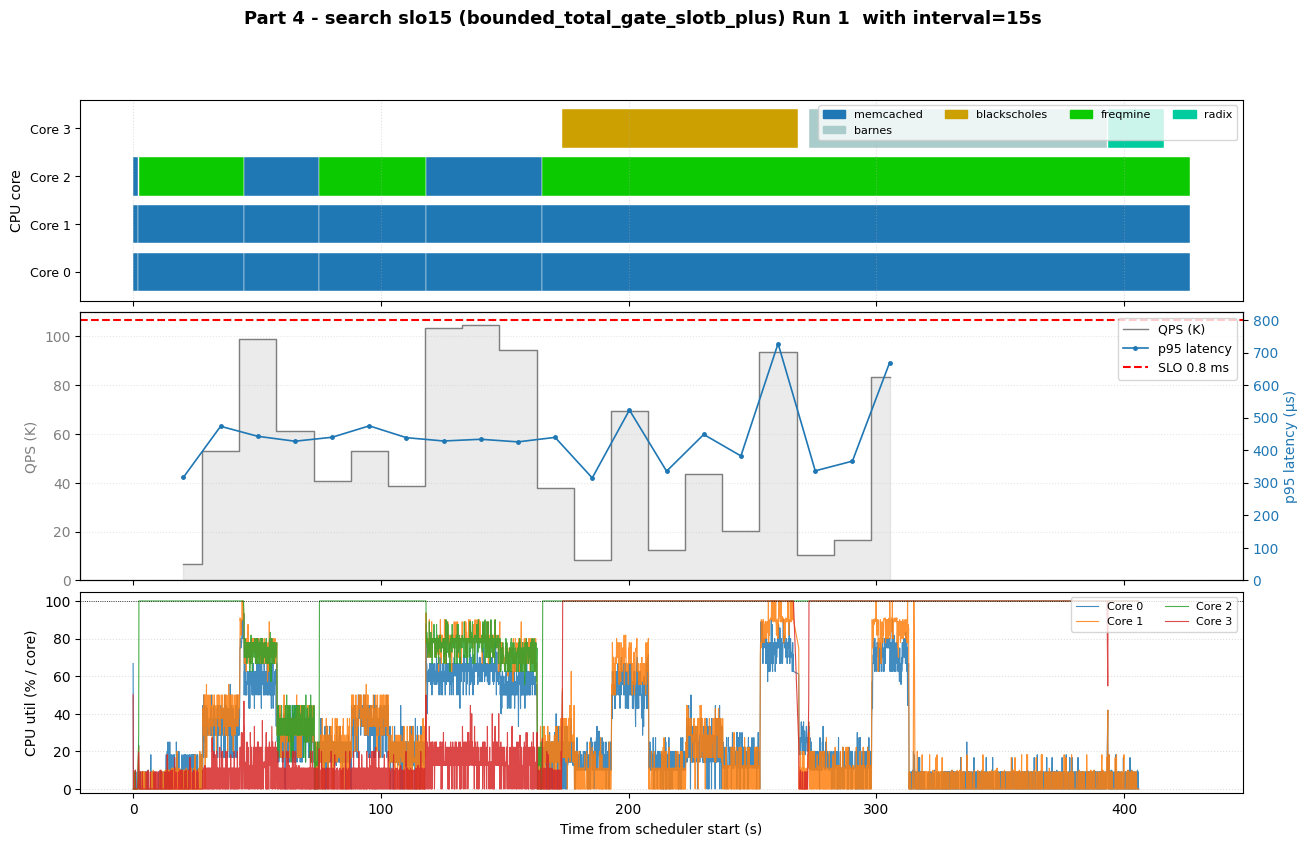

Run 1: 0/20 SLO violations (0.0%)
  max p95 = 727.6 µs  |  mean p95 = 442.1 µs
  CPU utilization per core:
    Core 0: mean= 26.3%  max= 93.3%  std= 24.4%
    Core 1: mean= 29.2%  max=100.0%  std= 31.5%
    Core 2: mean= 92.5%  max=100.0%  std= 18.2%
    Core 3: mean= 59.2%  max=100.0%  std= 46.3%
    Total:  mean= 51.8%  max=100.0%  std= 41.6%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_plus_run1.pdf



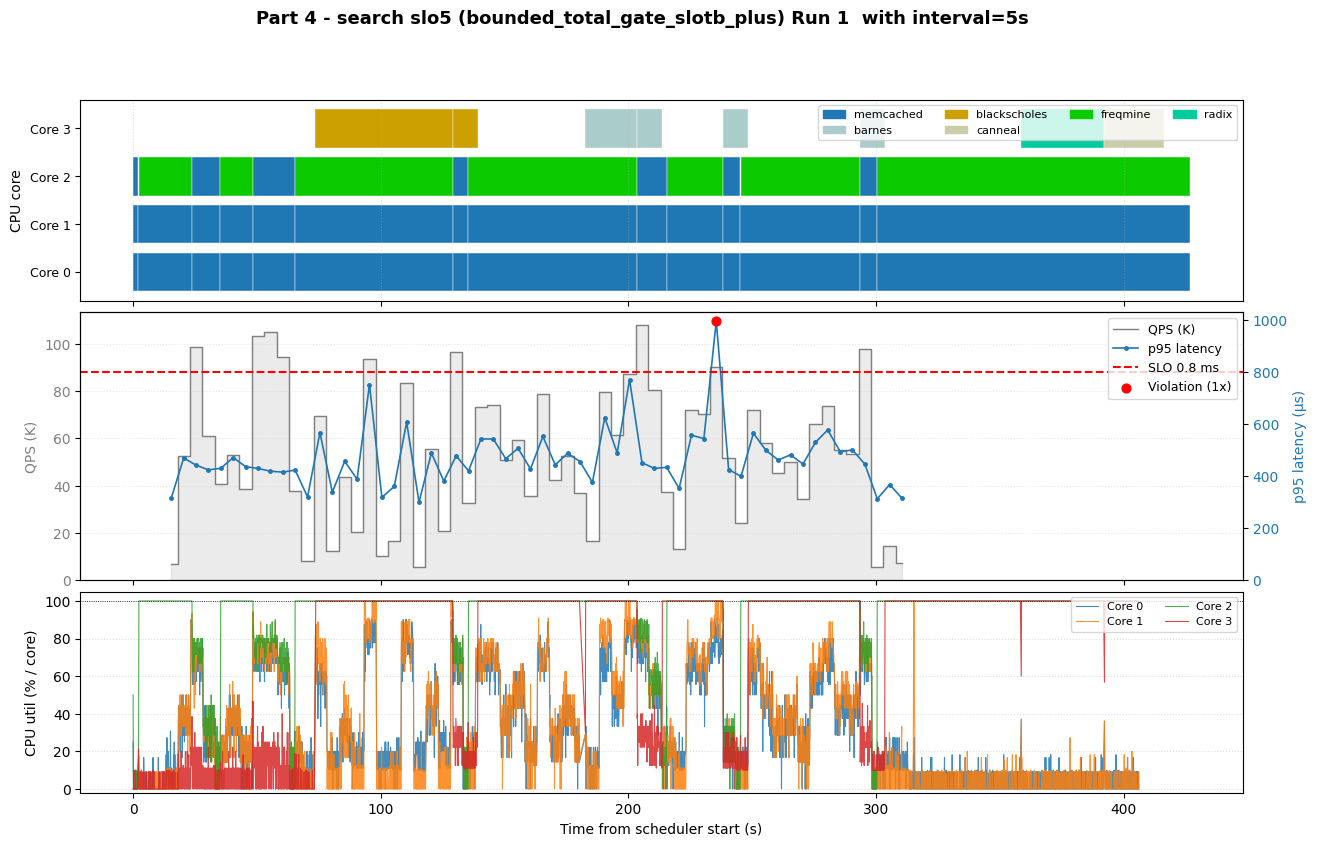

Run 1: 1/60 SLO violations (1.7%)
  max p95 = 995.5 µs  |  mean p95 = 469.0 µs
  CPU utilization per core:
    Core 0: mean= 30.6%  max=100.0%  std= 26.8%
    Core 1: mean= 31.2%  max=100.0%  std= 30.7%
    Core 2: mean= 92.5%  max=100.0%  std= 21.1%
    Core 3: mean= 74.7%  max=100.0%  std= 40.5%
    Total:  mean= 57.2%  max=100.0%  std= 40.9%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_plus_run1.pdf



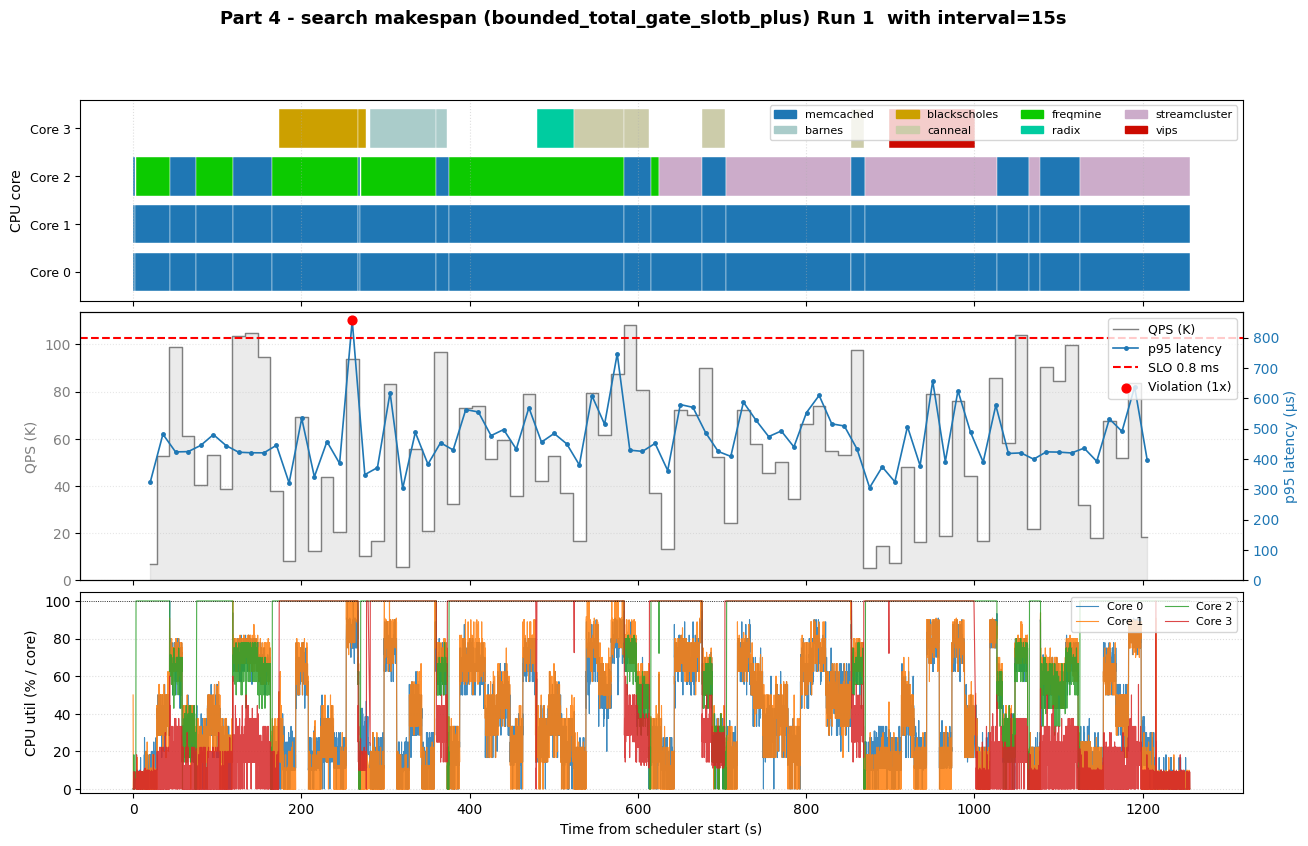

Run 1: 1/80 SLO violations (1.2%)
  max p95 = 856.8 µs  |  mean p95 = 468.2 µs
  CPU utilization per core:
    Core 0: mean= 40.4%  max=100.0%  std= 26.1%
    Core 1: mean= 40.0%  max=100.0%  std= 29.4%
    Core 2: mean= 89.6%  max=100.0%  std= 22.4%
    Core 3: mean= 63.3%  max=100.0%  std= 43.9%
    Total:  mean= 58.3%  max=100.0%  std= 37.5%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_plus_run1.pdf



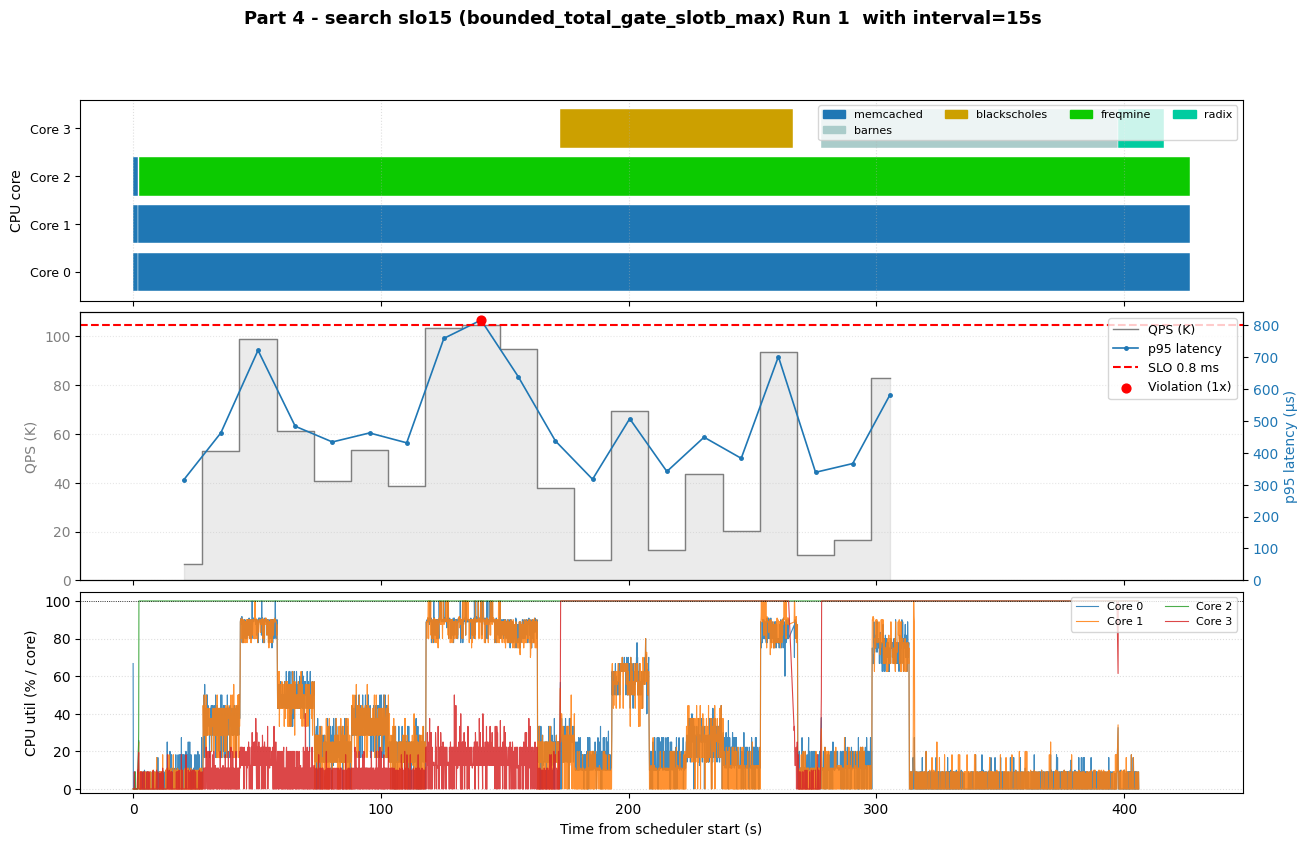

Run 1: 1/20 SLO violations (5.0%)
  max p95 = 816.6 µs  |  mean p95 = 497.6 µs
  CPU utilization per core:
    Core 0: mean= 32.0%  max=100.0%  std= 31.8%
    Core 1: mean= 29.8%  max=100.0%  std= 33.2%
    Core 2: mean= 99.5%  max=100.0%  std=  7.2%
    Core 3: mean= 57.9%  max=100.0%  std= 46.3%
    Total:  mean= 54.8%  max=100.0%  std= 43.2%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_max_run1.pdf



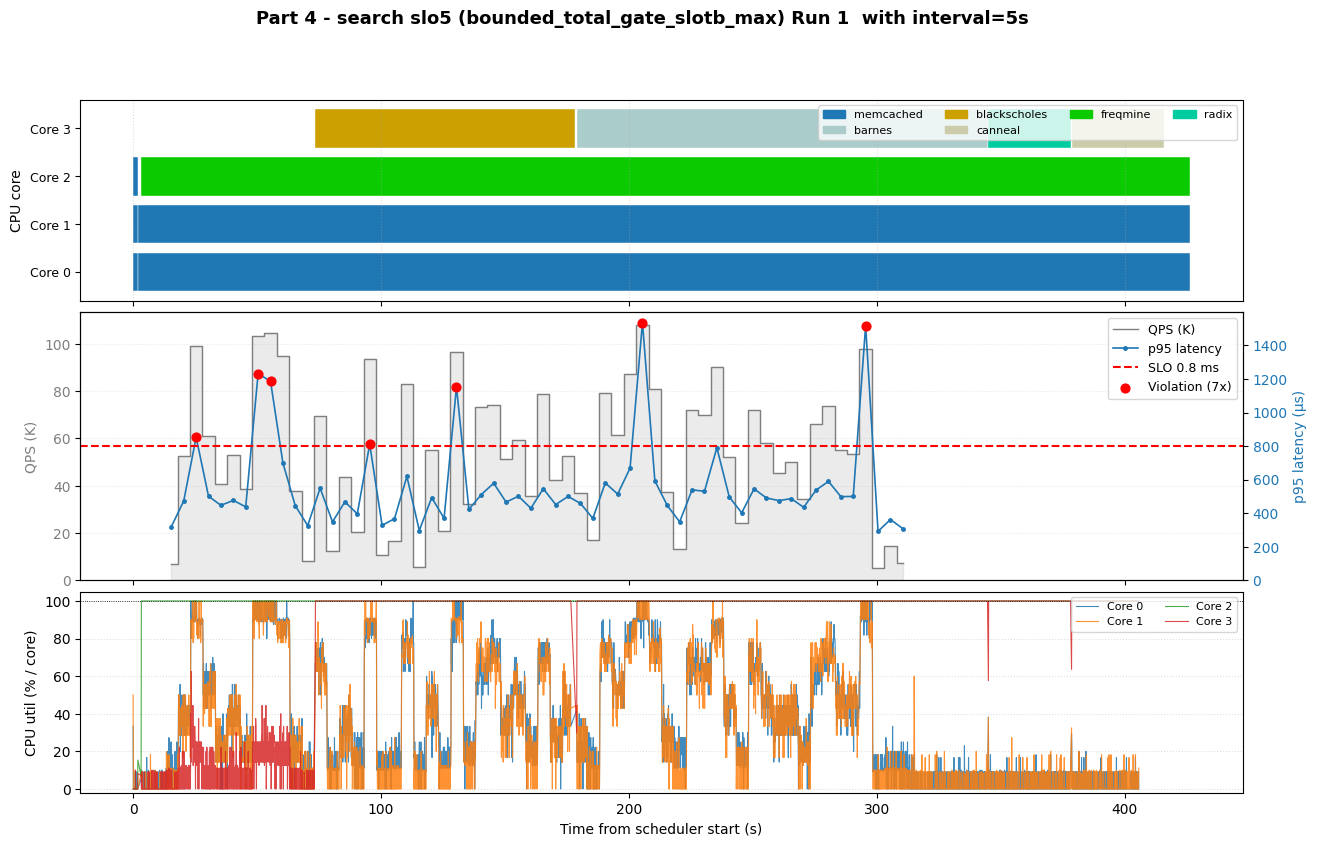

Run 1: 7/60 SLO violations (11.7%)
  max p95 = 1536.8 µs  |  mean p95 = 555.6 µs
  CPU utilization per core:
    Core 0: mean= 34.9%  max=100.0%  std= 31.2%
    Core 1: mean= 32.6%  max=100.0%  std= 32.3%
    Core 2: mean= 99.5%  max=100.0%  std=  7.3%
    Core 3: mean= 83.4%  max=100.0%  std= 35.5%
    Total:  mean= 62.6%  max=100.0%  std= 41.2%
  -> saved: ../reports/figures/p4/q4/bounded_total_gate_slotb_max_run1.pdf

Rendered 14 per-run plots across Phase-1 SLO checks and Phase-2 makespan runs.


In [95]:
# Discover which policies have data on disk.  The two-phase orchestrator
# (scripts/part-4-search.sh) writes:
#   data/p4/slo15/<policy>/run_1/   Phase 1, qps_interval=15
#   data/p4/slo5/<policy>/run_1/    Phase 1, qps_interval=5
#   data/p4/search/<policy>/run_1/         Phase 2, only if both SLO < 3%
#
# We list the full candidate set in canonical order; cells below skip any
# policy whose data dir doesn't exist yet.
ALL_POLICIES = [
    # "static", "responsive", "aggressive", "throughput",
    # "smart", "smart_fast", "smart_eager", "smart_safe",
    # "bounded", "bounded_react", "bounded_fast", "bounded_preempt", "bounded_conservative", "bounded_tuned", "bounded_filtered", "bounded_throttled",
    # "bounded_total", "bounded_total_v3", "bounded_total_guard", "bounded_total_stable", "bounded_total_hybrid", "bounded_total_adaptive",
    # "bounded_total_admit", "bounded_total_warm", "bounded_total_gate", "bounded_total_gate_fast", "bounded_total_gate_slotb",
    "bounded_total_gate_slotb_wide", "bounded_total_gate_slotb_more", "bounded_total_gate_slotb_finish", "bounded_total_gate_slotb_plus", "bounded_total_gate_slotb_max"
]
SEARCH_INTERVAL_S    = 15    # qps_interval for the Phase-2 makespan runs
SLO_CHECK_INTERVALS  = [15, 5]
SLO_THRESHOLD_PCT    = 3.0   # the constraint from the project handout
SEARCH_DURATION_S    = 1200  # Phase-2 mcperf duration (set by Makefile / orchestrator)

# Phase-2 (makespan) directories - only policies that passed Phase 1.
SEARCH_DIRS = {p: Path(f"../data/p4/search/{p}") for p in ALL_POLICIES}
SEARCH_POLICIES = [p for p in ALL_POLICIES if (SEARCH_DIRS[p] / "run_1" / "mcperf_1.txt").exists()]

# Phase-1 (SLO check) directories.
SLO_DIRS = {(p, i): Path(f"../data/p4/slo{i}/{p}")
            for p in ALL_POLICIES for i in SLO_CHECK_INTERVALS}

# Render a 3-panel plot for every (policy, source) combination that has data.
# Sources: Phase-1 SLO check at 15s, Phase-1 SLO check at 5s, Phase-2 makespan.
plotted = 0
for policy in ALL_POLICIES:
    for iv in SLO_CHECK_INTERVALS:
        dd = SLO_DIRS[(policy, iv)]
        if (dd / "run_1" / "mcperf_1.txt").exists():
            plot_run(dd, 1, iv, label=f"search slo{iv} ({policy}) ")
            plotted += 1
    dd2 = SEARCH_DIRS[policy]
    if (dd2 / "run_1" / "mcperf_1.txt").exists():
        plot_run(dd2, 1, SEARCH_INTERVAL_S, label=f"search makespan ({policy}) ")
        plotted += 1

if plotted == 0:
    print("No search data on disk yet.  Run:  make start-search/all")
else:
    print(f"Rendered {plotted} per-run plots across Phase-1 SLO checks and Phase-2 makespan runs.")


### Phase 1

SLO check with 5 min * policy * {qps_interval=15, qps_interval=5})

The project SLO constraint is p95 read latency <= 0.8 ms
in at least 97 % of mcperf intervals (SLO violations < 3 %),
and the orchestrator enforces this on both
`qps_interval = 15 s` and `qps_interval = 5 s`
before any policy proceeds to the makespan phase.
The cell below scans `data/p4/search/slo{15,5}-<policy>/run_1/mcperf_1.txt`
and prints the violation matrix.

policy             SLO@15s      SLO@5s   verdict
----------------------------------------------------
bounded_total_gate_slotb_wide      0.00%        0.00%     PASS
bounded_total_gate_slotb_more      0.00%        0.00%     PASS
bounded_total_gate_slotb_finish      0.00%        0.00%     PASS
bounded_total_gate_slotb_plus      0.00%        1.67%     PASS
bounded_total_gate_slotb_max      5.00% !     11.67% !   FAIL


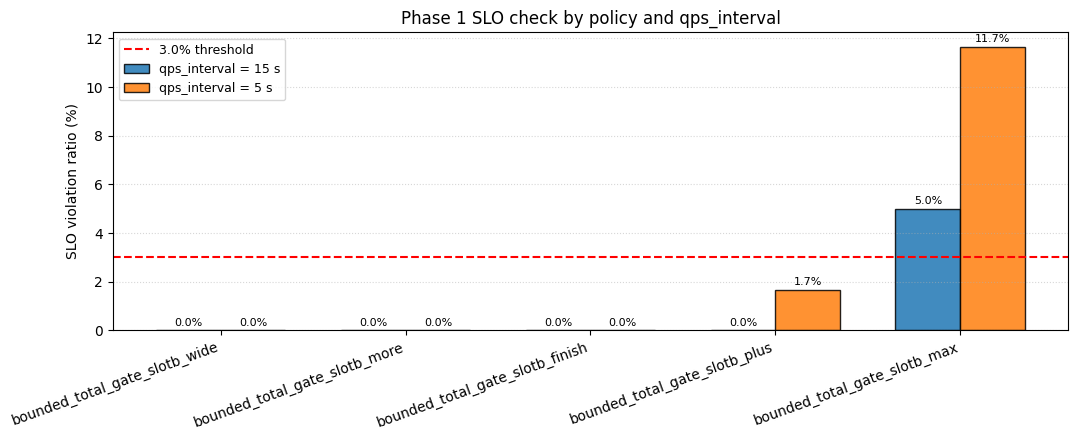

In [96]:
# Phase 1: SLO violation matrix per policy and per qps_interval.
# A policy must satisfy SLO < 3 % on BOTH intervals to be considered viable.
def _slo_pct(path):
    viols = total = 0
    try:
        with open(path) as fh:
            for line in fh:
                if not line.startswith("read"):
                    continue
                cols = line.split()
                try:
                    p95 = float(cols[12])
                except (IndexError, ValueError):
                    continue
                total += 1
                if p95 > SLO_US:
                    viols += 1
    except FileNotFoundError:
        return None
    return 100.0 * viols / total if total else None


print(f"{'policy':<14}" + "".join(f"{'SLO@'+str(i)+'s':>12}" for i in SLO_CHECK_INTERVALS)
      + "   verdict")
print("-" * (14 + 12 * len(SLO_CHECK_INTERVALS) + 14))
slo_table = []
for policy in ALL_POLICIES:
    row = {"policy": policy}
    for i in SLO_CHECK_INTERVALS:
        path = SLO_DIRS[(policy, i)] / "run_1" / "mcperf_1.txt"
        row[i] = _slo_pct(path)
    cells = []
    pcts  = []
    for i in SLO_CHECK_INTERVALS:
        v = row[i]
        if v is None:
            cells.append(f"{'-':>12}")
        else:
            cells.append(f"{v:>10.2f}%" + (" !" if v >= SLO_THRESHOLD_PCT else "  "))
            pcts.append(v)
    if pcts and len(pcts) == len(SLO_CHECK_INTERVALS) and all(v < SLO_THRESHOLD_PCT for v in pcts):
        verdict = "PASS"
    elif pcts:
        verdict = "FAIL"
    else:
        verdict = "(no data)"
    print(f"{policy:<14}" + "".join(cells) + f"   {verdict}")
    slo_table.append(row | {"verdict": verdict})

# Bar chart: SLO % per policy / per interval
slo_for_plot = [r for r in slo_table if any(r[i] is not None for i in SLO_CHECK_INTERVALS)]
if slo_for_plot:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(slo_for_plot))
    width = 0.35
    colors = ["#1f77b4", "#ff7f0e"]
    for j, iv in enumerate(SLO_CHECK_INTERVALS):
        vals = [r[iv] if r[iv] is not None else 0.0 for r in slo_for_plot]
        bars = ax.bar(x + (j - 0.5) * width, vals, width,
                      color=colors[j], alpha=0.85, edgecolor="black",
                      label=f"qps_interval = {iv} s")
        for b, v, r in zip(bars, vals, slo_for_plot):
            if r[iv] is None:
                continue
            ax.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v:.1f}%",
                    ha="center", fontsize=8)
    ax.axhline(SLO_THRESHOLD_PCT, color="red", lw=1.5, ls="--",
               label=f"{SLO_THRESHOLD_PCT}% threshold")
    ax.set_xticks(x)
    ax.set_xticklabels([r["policy"] for r in slo_for_plot], rotation=20, ha="right")
    ax.set_ylabel("SLO violation ratio (%)")
    ax.set_title("Phase 1 SLO check by policy and qps_interval")
    ax.legend(fontsize=9)
    ax.grid(axis="y", ls=":", alpha=0.5)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(FIG_SEARCH / "search_phase1_slo.pdf", bbox_inches="tight")
    plt.show()
else:
    print("\nNo Phase-1 data on disk yet.  Collect with: make start-search/all")


### Job runtimes, makespan, and SLO violations

Single-run statistics per policy. Per-job duration, total makespan (first batch container start -> last batch container end), and SLO violation ratio over the batch window. Computed with the same `job_durations_and_window()` / `slo_violations_in_window()` helpers used for Q3 and Q4.

In [97]:
# Search: per-policy makespan + per-job durations + SLO violation table.
# Reuses parse_jobs(), parse_mcperf(), job_durations_and_window(),
# slo_violations_in_window() defined earlier.
import statistics

search_stats = []
for policy in SEARCH_POLICIES:
    dd = SEARCH_DIRS[policy]
    jobs_path   = dd / "run_1" / "jobs_1.txt"
    mcperf_path = dd / "run_1" / "mcperf_1.txt"
    if not jobs_path.exists() or not mcperf_path.exists():
        print(f"[{policy}] missing data - skipping")
        continue
    _, events = parse_jobs(jobs_path)
    durs, makespan, t0, t1 = job_durations_and_window(events)
    if t0 is None:
        print(f"[{policy}] no batch jobs ever started - skipping")
        continue

    # If no batch job has ended yet (run too short), use the end of the mcperf
    # trace as the upper bound of the SLO measurement window. Makespan is then
    # a lower bound (jobs are still running) flagged with '*' in the table.
    incomplete = (t1 is None)
    if incomplete:
        unix_start, intervals = parse_mcperf(mcperf_path)
        t1_unix = unix_start + len(intervals) * SEARCH_INTERVAL_S
        t1 = datetime.fromtimestamp(t1_unix, tz=timezone.utc)
        makespan = (t1 - t0).total_seconds()

    viols, total = slo_violations_in_window(dd, 1, SEARCH_INTERVAL_S, t0, t1)
    slo_pct = 100 * viols / total if total > 0 else 0.0
    n_total = len(JOBS_REPORT_ORDER)
    n_done  = len(durs)
    search_stats.append({
        "policy": policy,
        "makespan_s": makespan or 0.0,
        "incomplete": incomplete,
        "n_completed": n_done,
        "n_total": n_total,
        "slo_viols": viols,
        "slo_total": total,
        "slo_pct": slo_pct,
        "durations": durs,
    })

if not search_stats:
    print("\nNo usable search runs yet. Collect data with: make start-search/all")
else:
    # Summary
    print(f"{'Policy':<12} {'Makespan [s]':>16} {'Jobs done':>11} {'SLO violations':>20}")
    print("-" * 65)
    for s in search_stats:
        ms = f"{s['makespan_s']:.1f}" + (" *" if s['incomplete'] else "")
        print(f"{s['policy']:<12} {ms:>16} "
              f"{s['n_completed']:>3} / {s['n_total']:<5} "
              f"{s['slo_viols']:>5} / {s['slo_total']:<4} ({s['slo_pct']:>5.2f}%)")
    print("  (* = no batch job ended within the run; makespan is a lower bound)")

    # Per-job duration matrix
    print()
    print("Per-job duration [s]  (- = job did not complete within the run window):")
    header = f"{'Job':<16}" + "".join(f"{s['policy']:>14}" for s in search_stats)
    print(header)
    print("-" * len(header))
    for job in JOBS_REPORT_ORDER:
        cells = []
        for s in search_stats:
            d = s["durations"].get(job)
            cells.append(f"{d:>14.1f}" if d is not None else f"{'-':>14}")
        print(f"{job:<16}" + "".join(cells))
    print("-" * len(header))
    print(f"{'makespan':<16}" + "".join(
        f"{s['makespan_s']:>14.1f}" + ("*" if s['incomplete'] else " ")
        for s in search_stats
    ))


Policy           Makespan [s]   Jobs done       SLO violations
-----------------------------------------------------------------
bounded_total_gate_slotb_wide           1314.6   7 / 7         0 / 80   ( 0.00%)
bounded_total_gate_slotb_more           1314.3   7 / 7         0 / 80   ( 0.00%)
bounded_total_gate_slotb_finish           1314.0   7 / 7         0 / 80   ( 0.00%)
bounded_total_gate_slotb_plus           1252.9   7 / 7         1 / 80   ( 1.25%)
  (* = no batch job ended within the run; makespan is a lower bound)

Per-job duration [s]  (- = job did not complete within the run window):
Job             bounded_total_gate_slotb_widebounded_total_gate_slotb_morebounded_total_gate_slotb_finishbounded_total_gate_slotb_plus
--------------------------------------------------------------------------------------------------------------------------------------
streamcluster            312.5         404.8         171.3         631.0
freqmine                1001.8         909.2         929.9  

### Cross-policy comparison

Side-by-side bars: makespan (s) and SLO violation ratio (%) per policy.
Reference lines mark the legacy Q3 makespan (~1725 s)
and the **900 s target**, plus the **3 % SLO** ceiling used for Q4's interval sweep.

Reading the chart:
- shorter makespan bar = faster batch completion (better)
- shorter SLO bar = lower latency cost (better)
- the policy that minimises makespan **without** breaching 3 % SLO is the winner of the search.

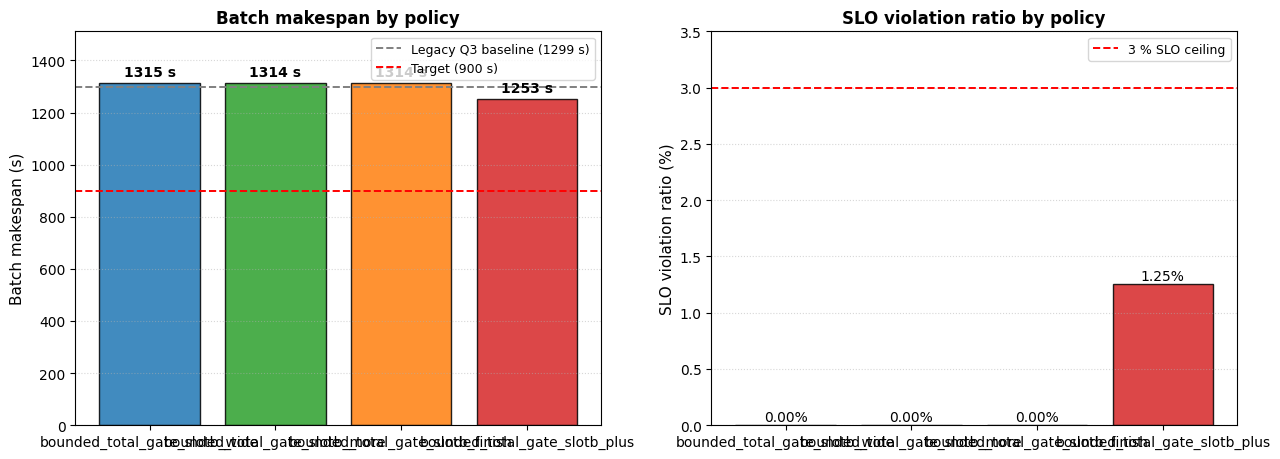


Winner (SLO < 3%): 'bounded_total_gate_slotb_plus'  makespan=1252.9 s  SLO=1.25%  speedup vs legacy = 1.04x


In [98]:
# Bar chart: makespan and SLO violation % side by side per policy.
if not search_stats:
    print("No search data yet - run: make start-search/all")
else:
    policies  = [s["policy"]     for s in search_stats]
    makespans = [s["makespan_s"] for s in search_stats]
    slo_pcts  = [s["slo_pct"]    for s in search_stats]

    # Pull the Q3 legacy baseline if it has already been computed in the Q3 cell;
    # otherwise fall back to the reported value.
    try:
        q3_baseline = float(np.mean([m for m in makespans_q3 if m]))   # noqa: F821
    except (NameError, TypeError):
        try:
            q3_baseline = float(np.mean([m for m in makespans if m]))  # legacy Q3 var name
        except Exception:
            q3_baseline = 1725.0

    colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

    fig, (ax_ms, ax_slo) = plt.subplots(1, 2, figsize=(13, 4.7))

    bars_ms = ax_ms.bar(policies, makespans, color=colors[:len(policies)],
                        alpha=0.85, edgecolor="black")
    ax_ms.axhline(q3_baseline, color="grey", ls="--", lw=1.4,
                  label=f"Legacy Q3 baseline ({q3_baseline:.0f} s)")
    ax_ms.axhline(900, color="red", ls="--", lw=1.4, label="Target (900 s)")
    ax_ms.set_ylabel("Batch makespan (s)", fontsize=11)
    ax_ms.set_title("Batch makespan by policy", fontsize=12, fontweight="bold")
    ax_ms.legend(fontsize=9, loc="upper right")
    for b, v, s in zip(bars_ms, makespans, search_stats):
        suffix = "*" if s["incomplete"] else ""
        ax_ms.text(b.get_x() + b.get_width() / 2, v + max(makespans) * 0.02,
                   f"{v:.0f} s{suffix}", ha="center", fontsize=10, fontweight="bold")
    ax_ms.grid(axis="y", ls=":", alpha=0.5)
    ax_ms.set_ylim(0, max(max(makespans), q3_baseline) * 1.15)

    bars_slo = ax_slo.bar(policies, slo_pcts, color=colors[:len(policies)],
                          alpha=0.85, edgecolor="black")
    ax_slo.axhline(3.0, color="red", ls="--", lw=1.4, label="3 % SLO ceiling")
    ax_slo.set_ylabel("SLO violation ratio (%)", fontsize=11)
    ax_slo.set_title("SLO violation ratio by policy", fontsize=12, fontweight="bold")
    ax_slo.legend(fontsize=9, loc="upper right")
    for b, v in zip(bars_slo, slo_pcts):
        ax_slo.text(b.get_x() + b.get_width() / 2,
                    v + max(max(slo_pcts), 1.0) * 0.03,
                    f"{v:.2f}%", ha="center", fontsize=10)
    ax_slo.grid(axis="y", ls=":", alpha=0.5)
    ax_slo.set_ylim(0, max(max(slo_pcts) * 1.2, 3.5))

    plt.tight_layout()
    if any(s["incomplete"] for s in search_stats):
        fig.text(0.5, -0.02,
                 "* makespan is a lower bound (some jobs were still running when the run ended)",
                 ha="center", fontsize=9, color="grey", style="italic")
    plt.savefig(FIG_SEARCH / "search_comparison.pdf", bbox_inches="tight")
    plt.show()

    # Pick the winner: shortest makespan among policies with slo_pct < 3%
    eligible = [s for s in search_stats if s["slo_pct"] < 3.0]
    if eligible:
        winner = min(eligible, key=lambda s: s["makespan_s"])
        speedup = q3_baseline / winner["makespan_s"] if winner["makespan_s"] > 0 else float("inf")
        print(f"\nWinner (SLO < 3%): '{winner['policy']}'  "
              f"makespan={winner['makespan_s']:.1f} s  "
              f"SLO={winner['slo_pct']:.2f}%  "
              f"speedup vs legacy = {speedup:.2f}x")
    else:
        print("\nNo policy stayed under 3 % SLO - consider relaxing throughput's expand threshold.")